2026-05-02 08:53:41.861617: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777712022.061347      65 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777712022.117613      65 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777712022.625455      65 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777712022.625474      65 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777712022.625476      65 computation_placer.cc:177] computation placer alr


  LOADING & PREPROCESSING DATA (Patient-wise split)
  Labels: Normal / Atrial / Other (3-class)

  Loading TRAIN patients ...


100%|██████████| 27/27 [00:33<00:00,  1.23s/it]



  Loading TEST patients ...


100%|██████████| 9/9 [00:11<00:00,  1.29s/it]


...

2026-05-02 08:54:42.392618: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


    Model: "MultiInput_BiLSTM_Attention"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wave_input          │ (None, 180, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_wave_1       │ (None, 180, 128)  │     33,792 │ wave_input[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 180, 128)  │        256 │ bilstm_wave_1[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_input          │ (None, 29) 

    Model: "LSTM_Denoising_Autoencoder"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_ecg (InputLayer)          │ (None, 180, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 180, 96)        │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 48)             │        23,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 48)             │            96 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ 

2026-05-02 09:55:25.902744: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


429/429 - 72s - 169ms/step - loss: 0.8354 - val_loss: 0.7889
Epoch 2/20
429/429 - 66s - 154ms/step - loss: 0.1936 - val_loss: 0.3110
Epoch 3/20
429/429 - 66s - 153ms/step - loss: 0.0887 - val_loss: 0.2123
Epoch 4/20
429/429 - 66s - 154ms/step - loss: 0.0698 - val_loss: 0.1567
Epoch 5/20
429/429 - 66s - 154ms/step - loss: 0.0537 - val_loss: 0.1059
Epoch 6/20
429/429 - 66s - 154ms/step - loss: 0.0455 - val_loss: 0.0888
Epoch 7/20
429/429 - 66s - 154ms/step - loss: 0.0410 - val_loss: 0.0548
Epoch 8/20
429/429 - 66s - 154ms/step - loss: 0.0381 - val_loss: 0.0931
Epoch 9/20
429/429 - 66s - 154ms/step - loss: 0.0349 - val_loss: 0.0543
Epoch 10/20
429/429 - 66s - 154ms/step - loss: 0.0371 - val_loss: 0.0879
Epoch 11/20
429/429 - 66s - 154ms/step - loss: 0.0318 - val_loss: 0.0919
Epoch 12/20
429/429 - 66s - 154ms/step - loss: 0.0302 - val_loss: 0.0768
Epoch 13/20
429/429 - 66s - 153ms/step - loss: 0.0279 - val_loss: 0.0855

  Applying DAE to denoise both train & test ...
  Applying SMOTE on de

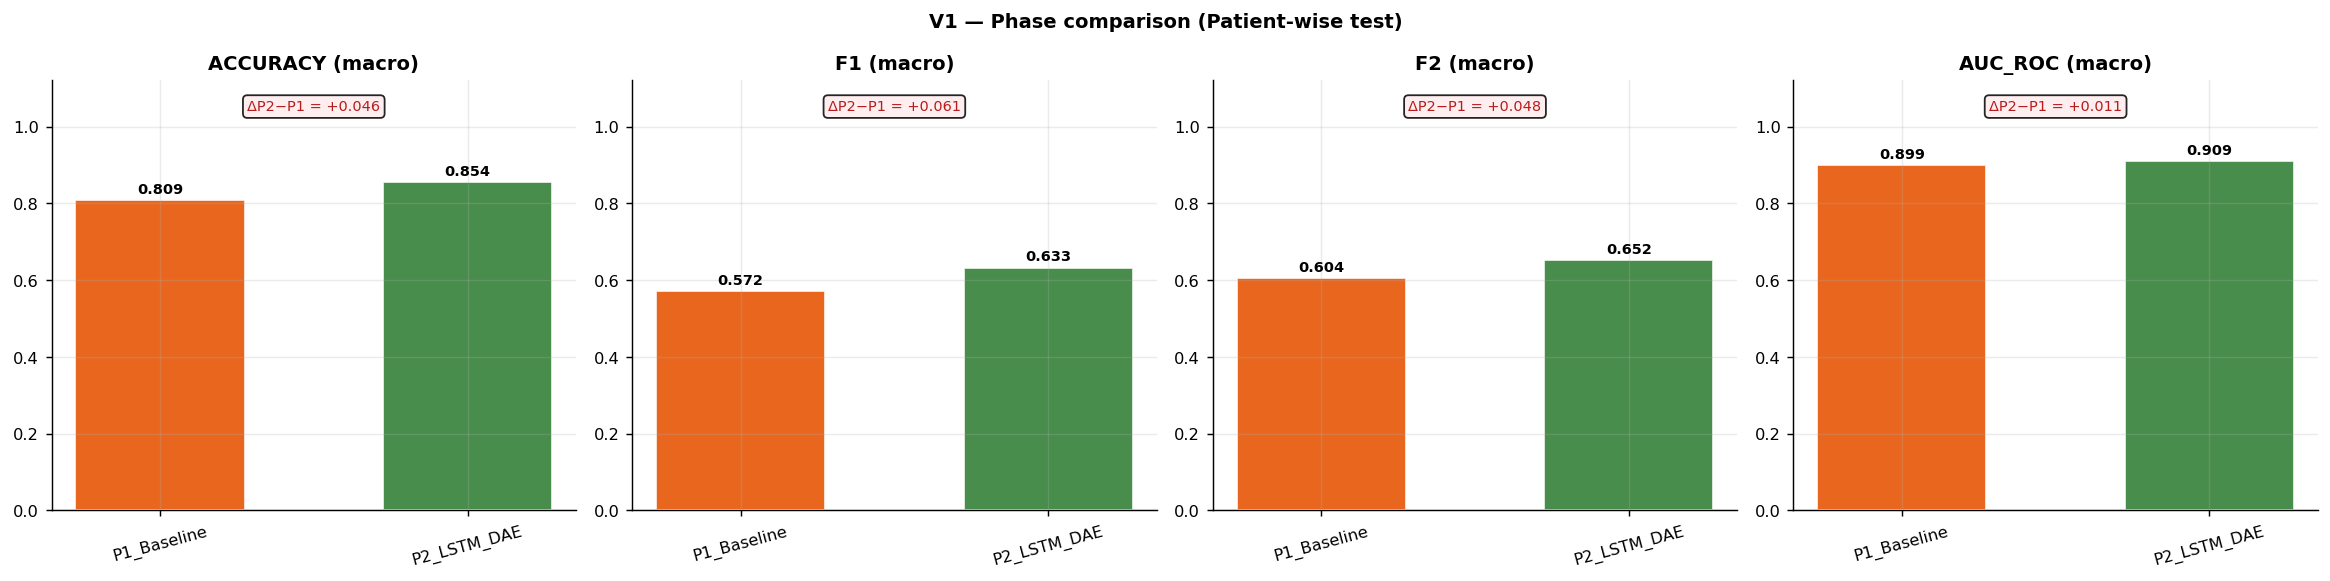

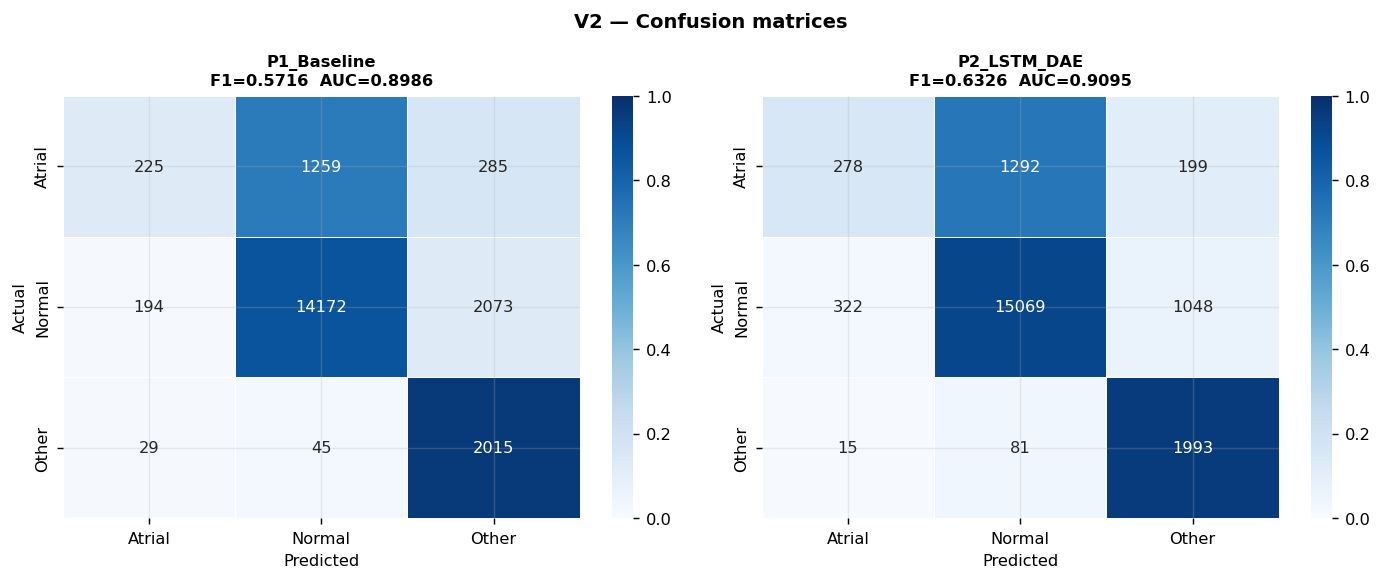

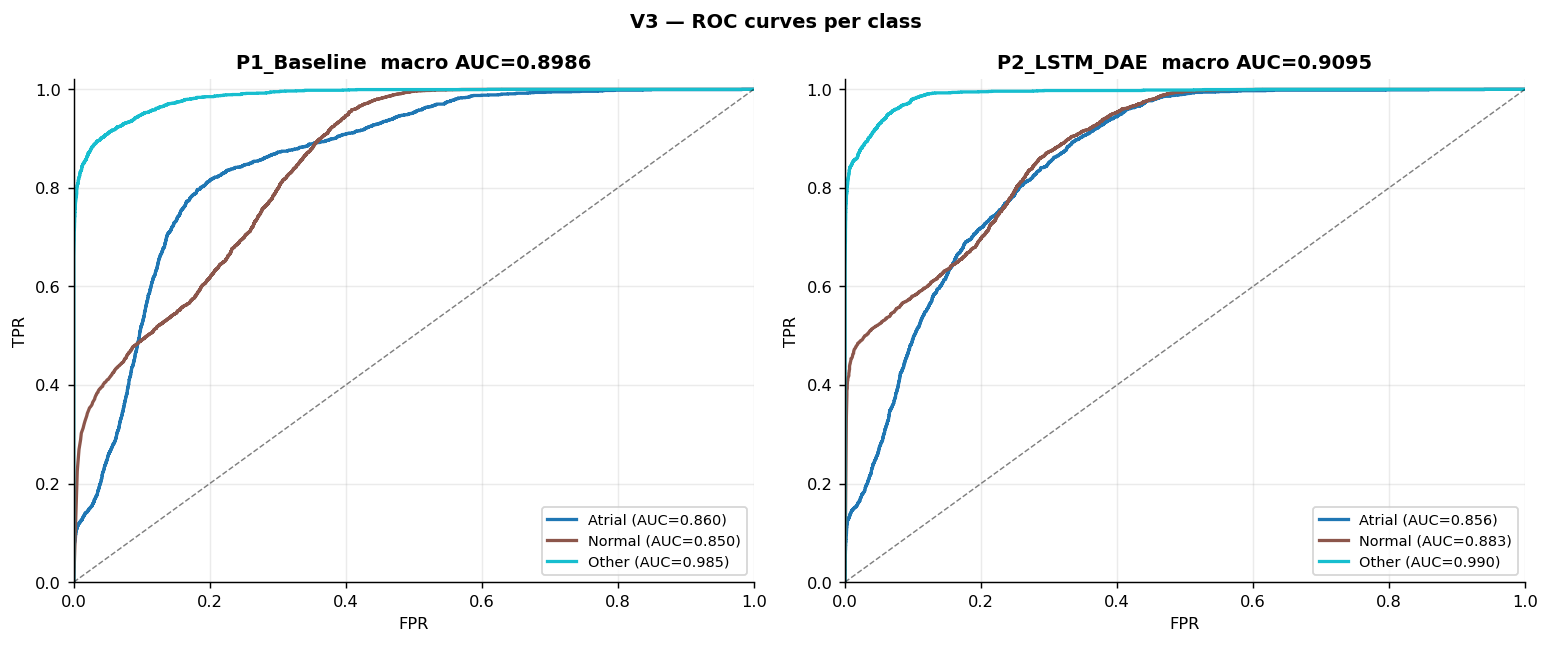

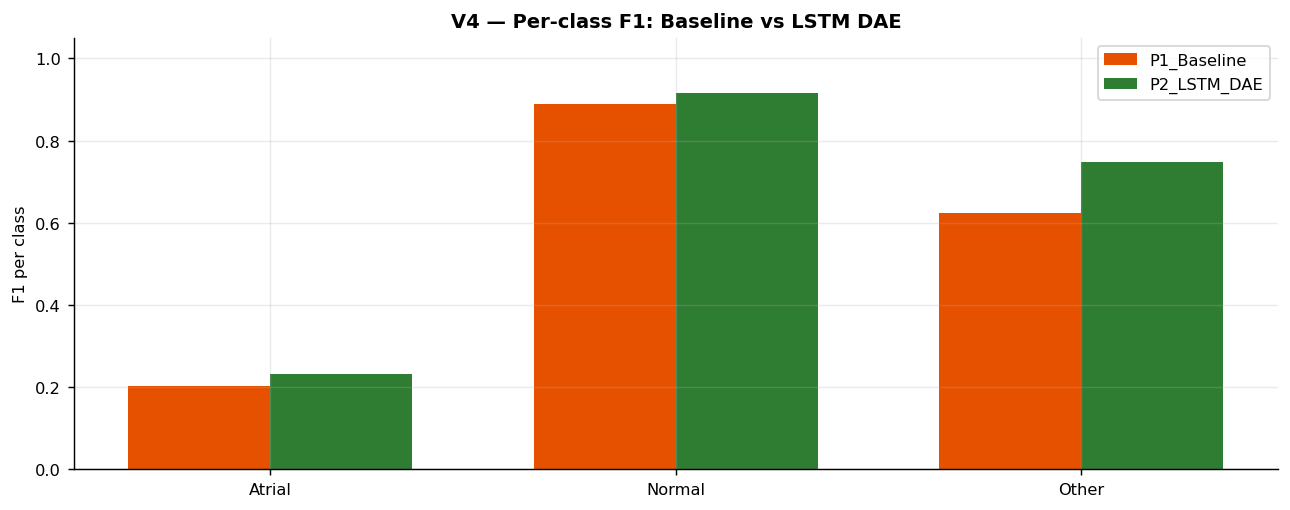

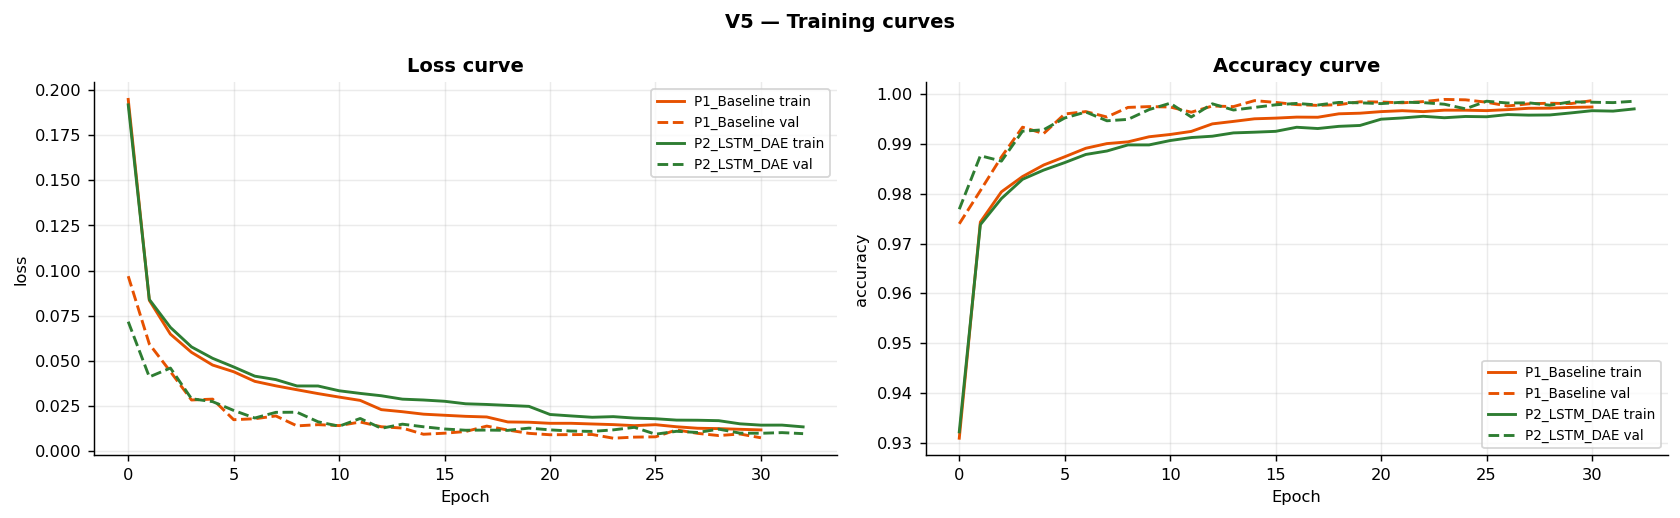

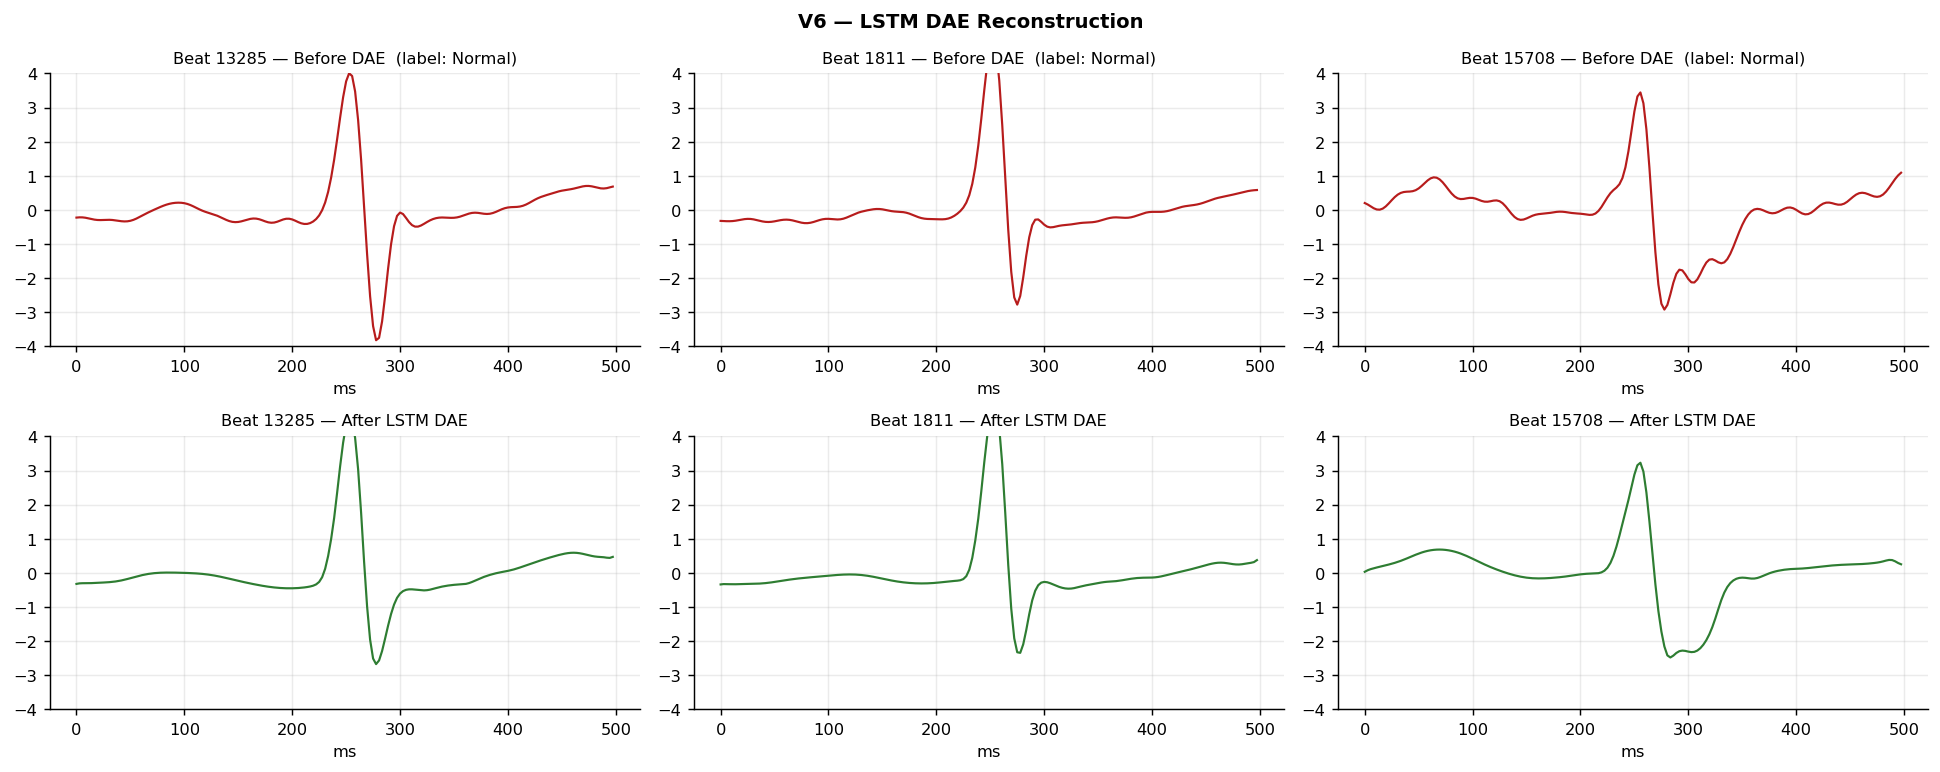

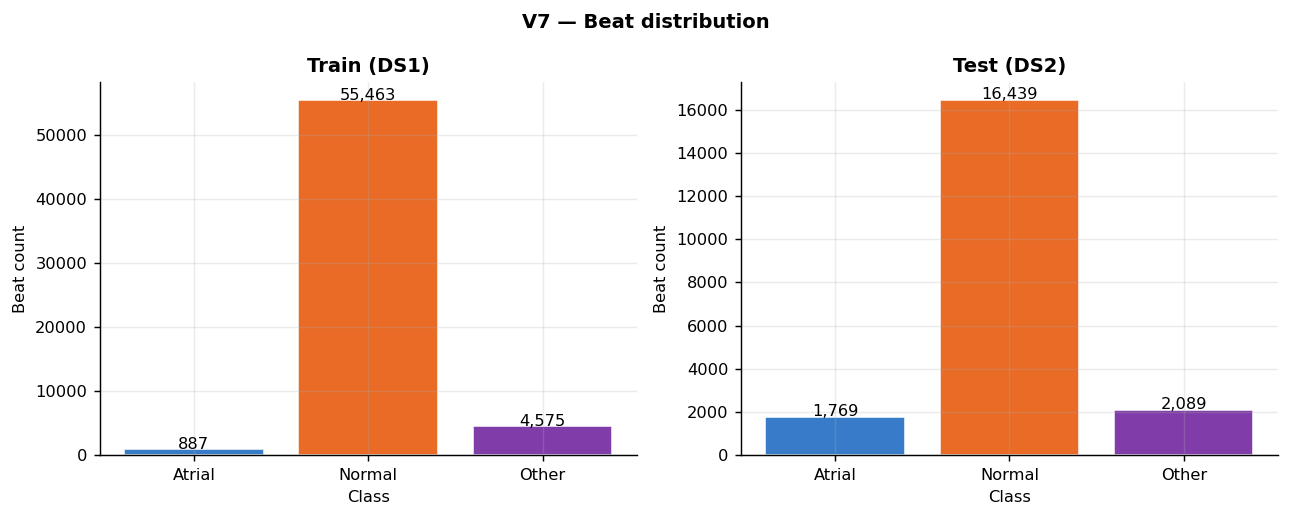


  Classification Report — P1_Baseline
              precision    recall  f1-score   support

      Atrial       0.50      0.13      0.20      1769
      Normal       0.92      0.86      0.89     16439
       Other       0.46      0.96      0.62      2089

    accuracy                           0.81     20297
   macro avg       0.63      0.65      0.57     20297
weighted avg       0.83      0.81      0.80     20297


  Classification Report — P2_LSTM_DAE
              precision    recall  f1-score   support

      Atrial       0.45      0.16      0.23      1769
      Normal       0.92      0.92      0.92     16439
       Other       0.62      0.95      0.75      2089

    accuracy                           0.85     20297
   macro avg       0.66      0.68      0.63     20297
weighted avg       0.84      0.85      0.84     20297


  BEST PHASE : P2_LSTM_DAE
  Accuracy   = 0.8543
  F1 macro   = 0.6326
  F2 macro   = 0.6522
  AUC-ROC    = 0.9095

  LSTM DAE gain (P2 − P1):
    ΔF1  = +0.06

In [1]:
# =============================================================================
#  ECG ARRHYTHMIA CLASSIFICATION — LSTM DENOISING AUTOENCODER PIPELINE
#  3-CLASS VERSION: Normal / Atrial / Other
#
#  KIẾN TRÚC TỔNG QUAN:
#    Input  : RR-interval features per beat  (RR, BPM, RR_z)  + raw beat waveform
#    Phase 1: Bandpass-filtered → BiLSTM + Attention Classifier (Baseline)
#    Phase 2: LSTM Denoising Autoencoder làm sạch waveform → BiLSTM Classifier
#
#  CẢI TIẾN SO VỚI NOTEBOOK GỐC:
#    1. Patient-wise split chuẩn (KHÔNG mix bệnh nhân vào train+test)
#    2. Multi-input model:
#         - Branch A: waveform (180 samples) → BiLSTM → Attention
#         - Branch B: sequence của RR/BPM/RR_z (10 beats) → BiLSTM
#         - Branch C: handcrafted morphological + wavelet features
#         → Concat → Dense → Softmax (3 classes)
#    3. LSTM-DAE để khử nhiễu (baseline wander, EMG, motion artifacts)
#    4. SMOTE để cân bằng class (Atrial thường <5% dataset)
#    5. Median filter (paper gốc) thay cho bandpass đơn thuần
#    6. Per-beat z-score normalization (raw MLII ~1000-2000)
#    7. Class weights để đối phó class imbalance
#    8. Đầy đủ metrics: Accuracy, F1-macro, F2-macro, Precision, Recall, AUC-ROC
# =============================================================================

import os, warnings, gc, random
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sps
from scipy.signal import medfilt, find_peaks
from scipy.stats import skew, kurtosis
import pywt
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, fbeta_score, accuracy_score,
                             precision_score, recall_score,
                             roc_auc_score, roc_curve, auc, confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE
from tqdm import tqdm

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)

import tensorflow as tf
from tensorflow.keras import layers, Model, Input, callbacks, optimizers
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 9,
})

# =============================================================================
# CONFIG
# =============================================================================
EXTRACT_DIR = '/kaggle/input/datasets/mondejar/mitbih-database'
FS          = 360
WB, WA      = 90, 90       # 90 samples trái/phải = 180 samples ~ 0.5s
BEAT_LEN    = WB + WA      # 180

# ── 3-CLASS MAPPING: Normal / Atrial / Other ──────────────────────────────────
#   Normal : N, L, R, e, j  (bao gồm bundle branch blocks — non-pathological rhythm)
#   Atrial : A, a, J, S      (Atrial premature, Aberrant APB, Nodal premature, SVEB)
#   Other  : V, E, F, /, f, Q (Ventricular ectopic, Fusion, Paced, Unknown)
LABEL_MAP = {
    'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal',
    'A': 'Atrial', 'a': 'Atrial', 'J': 'Atrial', 'S': 'Atrial',
    'V': 'Other',  'E': 'Other',  'F': 'Other',
    '/': 'Other',  'f': 'Other',  'Q': 'Other',
}
CLASSES_ORDER = ['Normal', 'Atrial', 'Other']
N_CLASSES     = 3

# ── Patient-wise split (gồm các record có MLII) ───────────────────────────────
#   Train  : 27 records
#   Test   : 9 records  (cố định, không trùng patient với train)
TRAIN_PATIENTS = [100, 101, 103, 105, 106, 108, 109, 111, 112, 115,
                  116, 117, 118, 119, 121, 122, 123, 124, 200, 201,
                  202, 203, 205, 207, 208, 209, 215]
TEST_PATIENTS  = [220, 221, 222, 223, 228, 230, 231, 232, 233]
# (Các record 102, 104, 107, 217 dùng paced rhythm — bỏ vì không phù hợp.
#  Record 114 bị đảo MLII/V1 — bỏ cho đơn giản; bạn có thể thêm lại nếu muốn.)

PALETTE = {
    'P1_Baseline' : '#E65100',
    'P2_LSTM_DAE' : '#2E7D32',
}

OUT_DIR = '/kaggle/working'
os.makedirs(OUT_DIR, exist_ok=True)

# Hyperparams
SEQ_LEN      = 10            # số beat liên tiếp dùng cho BiLSTM (RR sequence)
LSTM_UNITS   = 64
LSTM_DROPOUT = 0.3
LSTM_EPOCHS  = 40
LSTM_BATCH   = 128
LSTM_LR      = 1e-3


# =============================================================================
# 1. DATA LOADING — khớp với cấu trúc thực của mondejar dataset
# =============================================================================
def load_record(rid):
    """
    File CSV: '100.csv' — columns: 'sample #', 'MLII', 'V1' (raw int)
    File ANN: '100annotations.txt' — whitespace-sep:
              Time  Sample  Type  Sub  Chan  Num  Aux
    """
    csv_path = os.path.join(EXTRACT_DIR, f'{rid}.csv')
    ann_path = os.path.join(EXTRACT_DIR, f'{rid}annotations.txt')

    sig_df = pd.read_csv(csv_path)
    sig_df.columns = [c.strip().strip("'\"") for c in sig_df.columns]
    col_map = {c.upper(): c for c in sig_df.columns}

    mlii_col = col_map.get('MLII')
    if mlii_col is None:
        # Fallback: cột số đầu tiên không phải 'sample'
        num_cols = [c for c in sig_df.columns
                    if sig_df[c].dtype.kind in 'iuf' and 'sample' not in c.lower()]
        mlii_col = num_cols[0] if num_cols else None

    mlii = sig_df[mlii_col].interpolate('linear').ffill().bfill().values.astype(float)

    # Annotations
    beats_ann = []
    with open(ann_path, 'r') as f:
        next(f)  # skip header line
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            try:
                sample_pos = int(parts[1])
                beat_type  = parts[2]
                beats_ann.append((sample_pos, beat_type))
            except ValueError:
                continue

    return mlii, beats_ann, len(mlii)


# =============================================================================
# 2. PREPROCESSING
# =============================================================================
def remove_baseline(sig):
    """Median filter để loại baseline wander (paper gốc): kernel 71→215."""
    baseline = medfilt(sig, 71)
    baseline = medfilt(baseline, 215)
    return sig - baseline

def bandpass_filter(x, lo=0.5, hi=40.0, fs=FS, order=4):
    """Lọc băng thông sau khi loại baseline."""
    nyq  = fs / 2
    b, a = sps.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sps.filtfilt(b, a, np.asarray(x, dtype=float))

def preprocess_signal(sig):
    """Pipeline: baseline removal → bandpass."""
    sig = remove_baseline(sig.astype(float))
    sig = bandpass_filter(sig)
    return sig


# =============================================================================
# 3. RR / BPM / RR_z FEATURES (per beat) — như notebook gốc
# =============================================================================
def compute_rr_bpm_zscore(r_positions, fs=FS):
    """
    Trả về 3 array, mỗi array chiều dài = len(r_positions):
      RR    : khoảng cách (giây) tới beat trước
      BPM   : 60 / RR
      RR_z  : z-score của RR theo toàn record
    """
    n = len(r_positions)
    if n < 2:
        return np.zeros(n), np.zeros(n), np.zeros(n)

    rr_samples = np.diff(r_positions)
    rr_seconds = rr_samples / fs
    # Đặt RR cho beat đầu tiên = RR của beat thứ 2 để giữ độ dài
    RR  = np.concatenate([[rr_seconds[0]], rr_seconds])
    BPM = 60.0 / np.clip(RR, 0.2, 3.0)              # clip tránh chia 0

    mu, sd = RR.mean(), RR.std() + 1e-8
    RR_z   = (RR - mu) / sd
    return RR, BPM, RR_z


# =============================================================================
# 4. MORPHOLOGICAL + WAVELET FEATURES
# =============================================================================
def feat_morph(b):
    b = np.asarray(b, dtype=float)
    return [
        b.mean(), b.std(), b.min(), b.max(),
        float(b.argmax()) / len(b),
        float(b.argmin()) / len(b),
        float(skew(b)), float(kurtosis(b)),
        float(np.trapz(np.abs(b))),
        float(np.sum(np.diff(b)**2)),
        float(np.max(np.abs(np.diff(b)))),
        float(np.sum(b > 0)) / len(b),
        float(np.percentile(b, 25)),
        float(np.percentile(b, 75)),
    ]

def feat_wavelet(b, wavelet='db1', level=3):
    coeffs = pywt.wavedec(np.asarray(b, dtype=float), wavelet, level=level)
    feats = []
    for c in coeffs:
        feats += [float(np.sum(c**2)), float(np.abs(c).max()), float(c.mean())]
    return feats

def extract_handcrafted(beat, rr, bpm, rr_z):
    """Morph + Wavelet + 3 RR features."""
    return feat_morph(beat) + feat_wavelet(beat) + [rr, bpm, rr_z]

def sanitize(X):
    X = np.array(X, dtype=float)
    X = np.where(np.isinf(X), np.nan, X)
    df = pd.DataFrame(X)
    return df.interpolate('linear').ffill().bfill().fillna(0).values


# =============================================================================
# 5. BUILD DATASET (Patient-wise split)
# =============================================================================
print("\n" + "="*72)
print("  LOADING & PREPROCESSING DATA (Patient-wise split)")
print("  Labels: Normal / Atrial / Other (3-class)")
print("="*72)

def build_per_patient_beats(rid):
    """
    Trả về danh sách dict cho từng beat hợp lệ của bệnh nhân `rid`:
      { 'beat': np.array(BEAT_LEN), 'rr': float, 'bpm': float, 'rr_z': float,
        'feat': list, 'label': str, 'patient': int }
    """
    try:
        mlii, beats_ann, sig_len = load_record(rid)
    except FileNotFoundError:
        return []
    except Exception as e:
        print(f"  [WARN] record {rid}: {e}")
        return []

    sig_clean = preprocess_signal(mlii)

    # Lọc beat có symbol hợp lệ (có trong LABEL_MAP) và đủ window
    r_positions, labels = [], []
    for sample_pos, beat_type in beats_ann:
        if beat_type not in LABEL_MAP:
            continue
        if sample_pos - WB < 0 or sample_pos + WA >= sig_len:
            continue
        r_positions.append(sample_pos)
        labels.append(LABEL_MAP[beat_type])
    r_positions = np.array(r_positions)

    if len(r_positions) < 2:
        return []

    RR, BPM, RR_z = compute_rr_bpm_zscore(r_positions, fs=FS)

    out = []
    for i, (s, lab) in enumerate(zip(r_positions, labels)):
        beat = sig_clean[s - WB : s + WA]
        feat = extract_handcrafted(beat, RR[i], BPM[i], RR_z[i])
        out.append({
            'beat'   : beat.astype(np.float32),
            'rr'     : float(RR[i]),
            'bpm'    : float(BPM[i]),
            'rr_z'   : float(RR_z[i]),
            'feat'   : feat,
            'label'  : lab,
            'patient': rid,
        })
    return out


def build_dataset():
    """Build train + test theo patient-wise split."""
    train_beats, test_beats = [], []

    print("\n  Loading TRAIN patients ...")
    for rid in tqdm(TRAIN_PATIENTS):
        train_beats += build_per_patient_beats(rid)

    print("\n  Loading TEST patients ...")
    for rid in tqdm(TEST_PATIENTS):
        test_beats += build_per_patient_beats(rid)

    return train_beats, test_beats


train_beats, test_beats = build_dataset()
print(f"\n  Total train beats : {len(train_beats)}")
print(f"  Total test  beats : {len(test_beats)}")


# =============================================================================
# 6. CONVERT TO ARRAYS — gồm waveform, RR-sequence, handcrafted feats, labels
# =============================================================================
def beats_to_arrays(beats_list):
    W   = np.array([b['beat']  for b in beats_list], dtype=np.float32)[..., None]
    F   = np.array([b['feat']  for b in beats_list], dtype=np.float32)
    RR  = np.array([[b['rr'], b['bpm'], b['rr_z']] for b in beats_list],
                   dtype=np.float32)                                   # (N, 3)
    y   = np.array([b['label'] for b in beats_list])
    pid = np.array([b['patient'] for b in beats_list])
    return W, F, RR, y, pid

X_w_tr, X_f_tr, X_rr_tr, y_tr_raw, pid_tr = beats_to_arrays(train_beats)
X_w_te, X_f_te, X_rr_te, y_te_raw, pid_te = beats_to_arrays(test_beats)

# Encode labels (cố định thứ tự Normal/Atrial/Other)
le = LabelEncoder()
le.fit(CLASSES_ORDER)
y_tr_enc = le.transform(y_tr_raw)
y_te_enc = le.transform(y_te_raw)

print(f"\n  Classes     : {list(le.classes_)}")
print(f"  Train dist  : {dict(zip(*np.unique(y_tr_raw, return_counts=True)))}")
print(f"  Test  dist  : {dict(zip(*np.unique(y_te_raw, return_counts=True)))}")


# =============================================================================
# 7. SEQUENCE BUILDING (RR/BPM/RR_z trên 10 beat liên tiếp / patient)
# =============================================================================
def build_rr_sequences(X_rr, pid, seq_len=SEQ_LEN):
    """
    Với mỗi beat i, tạo sequence gồm SEQ_LEN beat trước đó (cùng patient).
    Nếu không đủ → pad bằng beat hiện tại.
    Trả về array (N, SEQ_LEN, 3).
    """
    N = len(X_rr)
    seqs = np.zeros((N, seq_len, 3), dtype=np.float32)
    for i in range(N):
        cur_pid = pid[i]
        # Tìm các beat trước i cùng patient
        start = max(0, i - seq_len + 1)
        # Cắt đoạn [start..i] và filter cùng patient
        candidate_idx = [j for j in range(start, i + 1) if pid[j] == cur_pid]
        seq = X_rr[candidate_idx]
        # Pad nếu thiếu (lặp beat đầu)
        if len(seq) < seq_len:
            pad = np.repeat(seq[:1], seq_len - len(seq), axis=0)
            seq = np.vstack([pad, seq])
        seqs[i] = seq[-seq_len:]
    return seqs

print("\n  Building RR sequences (10-beat windows per patient) ...")
X_seq_tr = build_rr_sequences(X_rr_tr, pid_tr)
X_seq_te = build_rr_sequences(X_rr_te, pid_te)
print(f"  Sequence shape — train: {X_seq_tr.shape}, test: {X_seq_te.shape}")


# =============================================================================
# 8. NORMALIZATION + SMOTE
# =============================================================================
def zscore_waveform(W):
    """Per-beat z-score (raw MLII có DC offset)."""
    mu = W.mean(axis=1, keepdims=True)
    sd = W.std(axis=1, keepdims=True) + 1e-8
    return (W - mu) / sd

X_w_tr_z = zscore_waveform(X_w_tr)
X_w_te_z = zscore_waveform(X_w_te)

# Standardize handcrafted feats
sc_f = StandardScaler()
X_f_tr_s = sc_f.fit_transform(X_f_tr)
X_f_te_s = sc_f.transform(X_f_te)

# Standardize RR-sequence (theo từng channel)
sc_rr = StandardScaler()
N_tr, T_seq, C = X_seq_tr.shape
X_seq_tr_s = sc_rr.fit_transform(X_seq_tr.reshape(-1, C)).reshape(N_tr, T_seq, C)
X_seq_te_s = sc_rr.transform(X_seq_te.reshape(-1, C)).reshape(len(X_seq_te), T_seq, C)


def apply_smote_multi(X_w, X_f, X_seq, y):
    """
    SMOTE trên 1 array gộp [waveform || feat || seq_flat] rồi tách lại.
    """
    Nw, T_w, _ = X_w.shape
    N_, T_s, C = X_seq.shape
    X_comb = np.hstack([X_w.reshape(Nw, T_w),
                        X_f,
                        X_seq.reshape(N_, T_s * C)])
    try:
        counts = np.bincount(y)
        min_c  = counts[counts > 0].min()
        k_nn   = max(1, min(5, min_c - 1))
        X_sm, y_sm = SMOTE(random_state=SEED, k_neighbors=k_nn).fit_resample(X_comb, y)
    except Exception as e:
        print(f"  [SMOTE warn] {e} — skipping SMOTE")
        return X_w, X_f, X_seq, y
    X_w_sm   = X_sm[:, :T_w].reshape(-1, T_w, 1)
    X_f_sm   = X_sm[:, T_w : T_w + X_f.shape[1]]
    X_seq_sm = X_sm[:, T_w + X_f.shape[1]:].reshape(-1, T_s, C)
    return X_w_sm, X_f_sm, X_seq_sm, y_sm

print("\n  Applying SMOTE ...")
X_w_tr_sm, X_f_tr_sm, X_seq_tr_sm, y_tr_sm = apply_smote_multi(
    X_w_tr_z, X_f_tr_s, X_seq_tr_s, y_tr_enc)
print(f"  Train after SMOTE: {len(y_tr_sm)}")
print(f"  Class dist after SMOTE: {dict(zip(*np.unique(y_tr_sm, return_counts=True)))}")


# =============================================================================
# 9. MODEL DEFINITIONS
# =============================================================================
class AttentionLayer(layers.Layer):
    """Bahdanau additive attention."""
    def __init__(self, units=64, **kw):
        super().__init__(**kw)
        self.units = units

    def build(self, input_shape):
        D = input_shape[-1]
        self.W = self.add_weight(shape=(D, self.units),
                                 initializer='glorot_uniform', name='W')
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='zeros', name='b')
        self.u = self.add_weight(shape=(self.units, 1),
                                 initializer='glorot_uniform', name='u')

    def call(self, x):
        uit = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        ait = tf.squeeze(tf.tensordot(uit, self.u, axes=1), -1)
        a   = tf.expand_dims(tf.nn.softmax(ait, axis=1), -1)
        return tf.reduce_sum(x * a, axis=1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units})
        return cfg


def build_lstm_dae(beat_len):
    """
    LSTM Denoising Autoencoder.
    Input  : noisy beat (beat_len, 1)
    Output : clean beat (beat_len, 1)
    """
    inp = Input(shape=(beat_len, 1), name='noisy_ecg')
    # Encoder
    x = layers.Bidirectional(layers.LSTM(48, return_sequences=True))(inp)
    x = layers.Bidirectional(layers.LSTM(24, return_sequences=False))(x)
    x = layers.LayerNormalization()(x)
    # Bottleneck
    x = layers.RepeatVector(beat_len)(x)
    # Decoder
    x = layers.Bidirectional(layers.LSTM(24, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(48, return_sequences=True))(x)
    out = layers.TimeDistributed(layers.Dense(1, activation='linear'),
                                  name='clean_ecg')(x)
    ae = Model(inp, out, name='LSTM_Denoising_Autoencoder')
    ae.compile(optimizer=optimizers.Adam(LSTM_LR), loss='mse')
    return ae


def build_multi_input_classifier(beat_len, n_feat, seq_len, seq_chan, n_classes):
    """
    Multi-branch model:
      A. Waveform branch  : (beat_len, 1) → BiLSTM stack → Attention
      B. RR-sequence branch: (seq_len, 3) → BiLSTM → last hidden
      C. Handcrafted branch: (n_feat,) → Dense
    Concat → Dense → Softmax(n_classes).
    """
    # Branch A: waveform morphology
    inp_w = Input(shape=(beat_len, 1), name='wave_input')
    a = layers.Bidirectional(
            layers.LSTM(LSTM_UNITS, return_sequences=True,
                        dropout=LSTM_DROPOUT,
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
            name='bilstm_wave_1')(inp_w)
    a = layers.LayerNormalization()(a)
    a = layers.Bidirectional(
            layers.LSTM(LSTM_UNITS, return_sequences=True,
                        dropout=LSTM_DROPOUT),
            name='bilstm_wave_2')(a)
    a = layers.LayerNormalization()(a)
    a = AttentionLayer(units=LSTM_UNITS, name='attention_wave')(a)

    # Branch B: RR / BPM / RR_z sequence
    inp_seq = Input(shape=(seq_len, seq_chan), name='rr_seq_input')
    b = layers.Bidirectional(
            layers.LSTM(32, return_sequences=True, dropout=LSTM_DROPOUT),
            name='bilstm_rr_1')(inp_seq)
    b = layers.Bidirectional(
            layers.LSTM(16, return_sequences=False, dropout=LSTM_DROPOUT),
            name='bilstm_rr_2')(b)

    # Branch C: handcrafted features
    inp_f = Input(shape=(n_feat,), name='feat_input')
    c = layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inp_f)
    c = layers.Dropout(LSTM_DROPOUT)(c)
    c = layers.Dense(32, activation='relu')(c)

    # Fusion
    z = layers.Concatenate()([a, b, c])
    z = layers.Dense(64, activation='relu')(z)
    z = layers.Dropout(LSTM_DROPOUT)(z)
    z = layers.Dense(32, activation='relu')(z)
    out = layers.Dense(n_classes, activation='softmax', name='output')(z)

    model = Model(inputs=[inp_w, inp_seq, inp_f], outputs=out,
                  name='MultiInput_BiLSTM_Attention')
    model.compile(optimizer=optimizers.Adam(LSTM_LR),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# =============================================================================
# 10. EVALUATION HELPERS
# =============================================================================
def evaluate_predictions(y_true, y_pred, y_proba, n_cls):
    m = {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall'   : recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1'       : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f2'       : fbeta_score(y_true, y_pred, average='macro', beta=2, zero_division=0),
    }
    try:
        yt_bin = label_binarize(y_true, classes=np.arange(n_cls))
        valid  = yt_bin.sum(axis=0) > 0
        m['auc_roc'] = (roc_auc_score(yt_bin[:, valid], y_proba[:, valid],
                                       multi_class='ovr', average='macro')
                        if valid.sum() > 1 else float('nan'))
    except Exception:
        m['auc_roc'] = float('nan')
    return m

def print_metrics(name, m):
    print(f"  [{name:18s}]  acc={m['accuracy']:.4f}  "
          f"F1={m['f1']:.4f}  F2={m['f2']:.4f}  AUC={m['auc_roc']:.4f}")


# =============================================================================
# 11. PHASE 1 — BASELINE (Filtered → BiLSTM Classifier)
# =============================================================================
print("\n" + "="*72)
print("  PHASE 1 — Baseline: Filtered → Multi-Input BiLSTM+Attention")
print("="*72)

tf.keras.backend.clear_session()
model_p1 = build_multi_input_classifier(
    beat_len=BEAT_LEN,
    n_feat=X_f_tr_sm.shape[1],
    seq_len=SEQ_LEN, seq_chan=3,
    n_classes=N_CLASSES,
)
print("\n  Model summary:")
model_p1.summary(print_fn=lambda s: print('    ' + s))

# Class weights (giúp khi SMOTE chưa đủ)
cw = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr_sm)
class_weight_dict = {i: w for i, w in enumerate(cw)}
print(f"\n  Class weights: {class_weight_dict}")

cb1 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7,
                            restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6),
]

print(f"\n  Training Phase 1 ({LSTM_EPOCHS} epochs max) ...")
hist_p1 = model_p1.fit(
    [X_w_tr_sm, X_seq_tr_sm, X_f_tr_sm],
    to_categorical(y_tr_sm, N_CLASSES),
    validation_split=0.15, epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH,
    callbacks=cb1, class_weight=class_weight_dict, verbose=2)

yprob_p1 = model_p1.predict(
    [X_w_te_z, X_seq_te_s, X_f_te_s],
    batch_size=LSTM_BATCH, verbose=0)
yp_p1 = yprob_p1.argmax(axis=1)

m_p1 = evaluate_predictions(y_te_enc, yp_p1, yprob_p1, N_CLASSES)
m_p1.update({'phase': 'P1_Baseline', 'y_true': y_te_enc,
             'y_pred': yp_p1, 'y_proba': yprob_p1, 'history': hist_p1.history})
print_metrics('P1_Baseline', m_p1)
model_p1.save(f'{OUT_DIR}/p1_baseline_classifier.keras')


# =============================================================================
# 12. PHASE 2 — LSTM DENOISING AUTOENCODER → BiLSTM Classifier
# =============================================================================
print("\n" + "="*72)
print("  PHASE 2 — LSTM DAE → Multi-Input BiLSTM+Attention")
print("="*72)

tf.keras.backend.clear_session()
dae_model = build_lstm_dae(BEAT_LEN)
print("\n  DAE architecture:")
dae_model.summary(print_fn=lambda s: print('    ' + s))

# Train DAE: noisy → clean
noise_factor = 0.4
X_w_tr_noisy = X_w_tr_z + noise_factor * np.random.randn(*X_w_tr_z.shape).astype(np.float32)
X_w_tr_noisy = np.clip(X_w_tr_noisy, -5., 5.)

print("\n  Training LSTM DAE (20 epochs max) ...")
cb_dae = [callbacks.EarlyStopping(monitor='val_loss', patience=4,
                                   restore_best_weights=True)]
dae_model.fit(X_w_tr_noisy, X_w_tr_z,
              epochs=20, batch_size=128, validation_split=0.1,
              callbacks=cb_dae, verbose=2)

print("\n  Applying DAE to denoise both train & test ...")
X_w_tr_den = dae_model.predict(X_w_tr_z, batch_size=128, verbose=0)
X_w_te_den = dae_model.predict(X_w_te_z, batch_size=128, verbose=0)

# SMOTE trên denoised data (giữ nguyên RR-seq và feat)
print("  Applying SMOTE on denoised data ...")
X_w_tr_den_sm, X_f_tr_sm_p2, X_seq_tr_sm_p2, y_tr_sm_p2 = apply_smote_multi(
    X_w_tr_den, X_f_tr_s, X_seq_tr_s, y_tr_enc)

classifier_p2 = build_multi_input_classifier(
    beat_len=BEAT_LEN,
    n_feat=X_f_tr_sm_p2.shape[1],
    seq_len=SEQ_LEN, seq_chan=3,
    n_classes=N_CLASSES,
)
cw2 = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr_sm_p2)
class_weight_dict2 = {i: w for i, w in enumerate(cw2)}

cb2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7,
                            restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6),
]

print(f"\n  Training Phase 2 ({LSTM_EPOCHS} epochs max) ...")
hist_p2 = classifier_p2.fit(
    [X_w_tr_den_sm, X_seq_tr_sm_p2, X_f_tr_sm_p2],
    to_categorical(y_tr_sm_p2, N_CLASSES),
    validation_split=0.15, epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH,
    callbacks=cb2, class_weight=class_weight_dict2, verbose=2)

yprob_p2 = classifier_p2.predict(
    [X_w_te_den, X_seq_te_s, X_f_te_s],
    batch_size=LSTM_BATCH, verbose=0)
yp_p2 = yprob_p2.argmax(axis=1)

m_p2 = evaluate_predictions(y_te_enc, yp_p2, yprob_p2, N_CLASSES)
m_p2.update({'phase': 'P2_LSTM_DAE', 'y_true': y_te_enc,
             'y_pred': yp_p2, 'y_proba': yprob_p2, 'history': hist_p2.history})
print_metrics('P2_LSTM_DAE', m_p2)

dae_model.save(f'{OUT_DIR}/p2_lstm_denoiser.keras')
classifier_p2.save(f'{OUT_DIR}/p2_dae_classifier.keras')


# =============================================================================
# 13. SUMMARY TABLE + VISUALIZATIONS
# =============================================================================
all_phases = [m_p1, m_p2]
classes    = list(le.classes_)

print("\n" + "="*72)
print("  CROSS-PHASE SUMMARY")
print("="*72)

rows = [{
    'phase'    : m['phase'],
    'accuracy' : round(m['accuracy'],  4),
    'precision': round(m['precision'], 4),
    'recall'   : round(m['recall'],    4),
    'f1'       : round(m['f1'],        4),
    'f2'       : round(m['f2'],        4),
    'auc_roc'  : round(m['auc_roc'],   4),
} for m in all_phases]
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(f'{OUT_DIR}/phase_summary.csv', index=False)


# ── V1: Metric comparison bars ───────────────────────────────────────────────
metrics_to_plot = ['accuracy', 'f1', 'f2', 'auc_roc']
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, mt in zip(axes, metrics_to_plot):
    vals  = [m[mt] for m in all_phases]
    names = [m['phase'] for m in all_phases]
    bars = ax.bar(names, vals, color=[PALETTE[p] for p in names],
                  edgecolor='white', alpha=0.88, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')
    delta = m_p2[mt] - m_p1[mt]
    sign  = '+' if delta >= 0 else ''
    ax.annotate(f'ΔP2−P1 = {sign}{delta:.3f}',
                xy=(0.5, 0.93), xycoords='axes fraction', ha='center',
                fontsize=8, color='#B71C1C',
                bbox=dict(boxstyle='round,pad=0.3', fc='#FFEBEE', alpha=0.85))
    ax.set_ylim(0, 1.12)
    ax.set_title(f'{mt.upper()} (macro)', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('V1 — Phase comparison (Patient-wise test)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V1_metric_comparison.png', bbox_inches='tight')
plt.show()

# ── V2: Confusion matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, m in zip(axes, all_phases):
    cm   = confusion_matrix(m['y_true'], m['y_pred'], labels=np.arange(N_CLASSES))
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_n, annot=cm, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                vmin=0, vmax=1, linewidths=0.4, ax=ax)
    ax.set_title(f"{m['phase']}\nF1={m['f1']:.4f}  AUC={m['auc_roc']:.4f}",
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.suptitle('V2 — Confusion matrices', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V2_confusion.png', bbox_inches='tight')
plt.show()

# ── V3: ROC curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cls_colors = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))
for ax, m in zip(axes, all_phases):
    yt_bin = label_binarize(m['y_true'], classes=np.arange(N_CLASSES))
    for i, cname in enumerate(classes):
        if yt_bin[:, i].sum() == 0: continue
        fpr, tpr, _ = roc_curve(yt_bin[:, i], m['y_proba'][:, i])
        ax.plot(fpr, tpr, color=cls_colors[i], lw=1.8,
                label=f'{cname} (AUC={auc(fpr, tpr):.3f})')
    ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f"{m['phase']}  macro AUC={m['auc_roc']:.4f}", fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('V3 — ROC curves per class', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V3_roc.png', bbox_inches='tight')
plt.show()

# ── V4: Per-class F1 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_CLASSES); width = 0.35
for i, m in enumerate(all_phases):
    cm = confusion_matrix(m['y_true'], m['y_pred'], labels=np.arange(N_CLASSES))
    f1s = []
    for c in range(N_CLASSES):
        tp = cm[c,c]; fp = cm[:,c].sum()-tp; fn = cm[c,:].sum()-tp
        p  = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
        f1s.append(2*p*rec/(p+rec+1e-9))
    ax.bar(x + i*width, f1s, width, color=PALETTE[m['phase']], label=m['phase'])
ax.set_xticks(x + width/2); ax.set_xticklabels(classes)
ax.set_ylabel('F1 per class'); ax.set_ylim(0, 1.05)
ax.set_title('V4 — Per-class F1: Baseline vs LSTM DAE', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V4_perclass_f1.png', bbox_inches='tight')
plt.show()

# ── V5: Training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, key in zip(axes, ['loss', 'accuracy']):
    for m in all_phases:
        h = m['history']
        ax.plot(h[key], color=PALETTE[m['phase']], lw=1.6,
                label=f"{m['phase']} train")
        ax.plot(h[f'val_{key}'], color=PALETTE[m['phase']], lw=1.6,
                ls='--', label=f"{m['phase']} val")
    ax.set_xlabel('Epoch'); ax.set_ylabel(key)
    ax.set_title(f'{key.capitalize()} curve', fontweight='bold')
    ax.legend(fontsize=7.5)
plt.suptitle('V5 — Training curves', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V5_training_curves.png', bbox_inches='tight')
plt.show()

# ── V6: DAE denoising effect ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(X_w_te_z), 3, replace=False)
t = np.arange(BEAT_LEN) / FS * 1000  # ms
for i, idx in enumerate(sample_indices):
    orig    = X_w_te_z[idx, :, 0]
    denoised = X_w_te_den[idx, :, 0]
    axes[0, i].plot(t, orig, color='#B71C1C', lw=1.2)
    axes[0, i].set_title(f'Beat {idx} — Before DAE  (label: {classes[y_te_enc[idx]]})',
                         fontsize=9)
    axes[0, i].set_ylim(-4, 4); axes[0, i].set_xlabel('ms')
    axes[1, i].plot(t, denoised, color='#2E7D32', lw=1.2)
    axes[1, i].set_title(f'Beat {idx} — After LSTM DAE', fontsize=9)
    axes[1, i].set_ylim(-4, 4); axes[1, i].set_xlabel('ms')
plt.suptitle('V6 — LSTM DAE Reconstruction', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V6_dae_effect.png', bbox_inches='tight')
plt.show()

# ── V7: Class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y, title) in zip(axes, [(y_tr_raw, 'Train (DS1)'),
                                  (y_te_raw, 'Test (DS2)')]):
    unique, counts = np.unique(y, return_counts=True)
    colors = ['#1565C0','#E65100','#6A1B9A'][:len(unique)]
    bars = ax.bar(unique, counts, color=colors, edgecolor='white', alpha=0.85)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{c:,}', ha='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Class'); ax.set_ylabel('Beat count')
plt.suptitle('V7 — Beat distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V7_class_distribution.png', bbox_inches='tight')
plt.show()


# =============================================================================
# 14. CLASSIFICATION REPORTS + PER-CLASS CSV
# =============================================================================
for m in all_phases:
    print(f"\n{'='*72}")
    print(f"  Classification Report — {m['phase']}")
    print(f"{'='*72}")
    print(classification_report(m['y_true'], m['y_pred'],
                                 target_names=classes, zero_division=0))

pc_rows = []
for m in all_phases:
    cm = confusion_matrix(m['y_true'], m['y_pred'], labels=np.arange(N_CLASSES))
    for ci, cname in enumerate(classes):
        tp = cm[ci,ci]; fp = cm[:,ci].sum()-tp; fn = cm[ci,:].sum()-tp
        p  = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
        f1 = 2*p*rec/(p+rec+1e-9)
        pc_rows.append({
            'phase': m['phase'], 'class': cname,
            'precision': round(p, 4), 'recall': round(rec, 4),
            'f1': round(f1, 4), 'support': int(cm[ci,:].sum())
        })
pd.DataFrame(pc_rows).to_csv(f'{OUT_DIR}/perclass_metrics.csv', index=False)


# =============================================================================
# 15. FINAL VERDICT
# =============================================================================
best = max(all_phases, key=lambda m: m['f1'])
print(f"\n{'='*72}")
print(f"  BEST PHASE : {best['phase']}")
print(f"  Accuracy   = {best['accuracy']:.4f}")
print(f"  F1 macro   = {best['f1']:.4f}")
print(f"  F2 macro   = {best['f2']:.4f}")
print(f"  AUC-ROC    = {best['auc_roc']:.4f}")
print(f"\n  LSTM DAE gain (P2 − P1):")
print(f"    ΔF1  = {m_p2['f1']  - m_p1['f1']:+.4f}")
print(f"    ΔAUC = {m_p2['auc_roc'] - m_p1['auc_roc']:+.4f}")
print(f"    ΔAcc = {m_p2['accuracy'] - m_p1['accuracy']:+.4f}")
print(f"\n  All outputs → {OUT_DIR}/")
print(f"{'='*72}")


  LOADING DATA — Patient-wise split, 3-class (Normal/Atrial/Other)

  Loading TRAIN patients ...


100%|██████████| 27/27 [00:30<00:00,  1.13s/it]



  Loading TEST patients ...


100%|██████████| 9/9 [00:10<00:00,  1.14s/it]



  Total train beats : 60925
  Total test  beats : 20297

  Classes     : [np.str_('Atrial'), np.str_('Normal'), np.str_('Other')]
  Train dist  : {np.str_('Atrial'): np.int64(887), np.str_('Normal'): np.int64(55463), np.str_('Other'): np.int64(4575)}
  Test  dist  : {np.str_('Atrial'): np.int64(1769), np.str_('Normal'): np.int64(16439), np.str_('Other'): np.int64(2089)}

  Building RR sequences (10-beat windows per patient) ...
  Sequence shape — train: (60925, 10, 3), test: (20297, 10, 3)

  PHASE 1 — PURE SARIMA likelihood classifier

  Fitting one SARIMA per class on RR-sequence ...
    Fitting class Normal (887 sequences) ...
    Fitting class Atrial (55463 sequences) ...
    Fitting class Other (4575 sequences) ...

  Predicting on test set with pure SARIMA ...


...

   ARIMA-denoising: 100%|██████████| 60925/60925 [50:55<00:00, 19.94it/s]



  Applying ARIMA denoising on test set ...


   ARIMA-denoising: 100%|██████████| 20297/20297 [18:02<00:00, 18.75it/s]



  Applying SMOTE on ARIMA-denoised data ...
  Train after SMOTE: 166389
  Class dist: {np.int64(0): np.int64(55463), np.int64(1): np.int64(55463), np.int64(2): np.int64(55463)}

  Classifier summary:


    Model: "ARIMA_Denoised_BiLSTM"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wave_input          │ (None, 180, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 180, 128)  │     33,792 │ wave_input[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 180, 128)  │        256 │ bidirectional[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_input          │ (None, 29)       

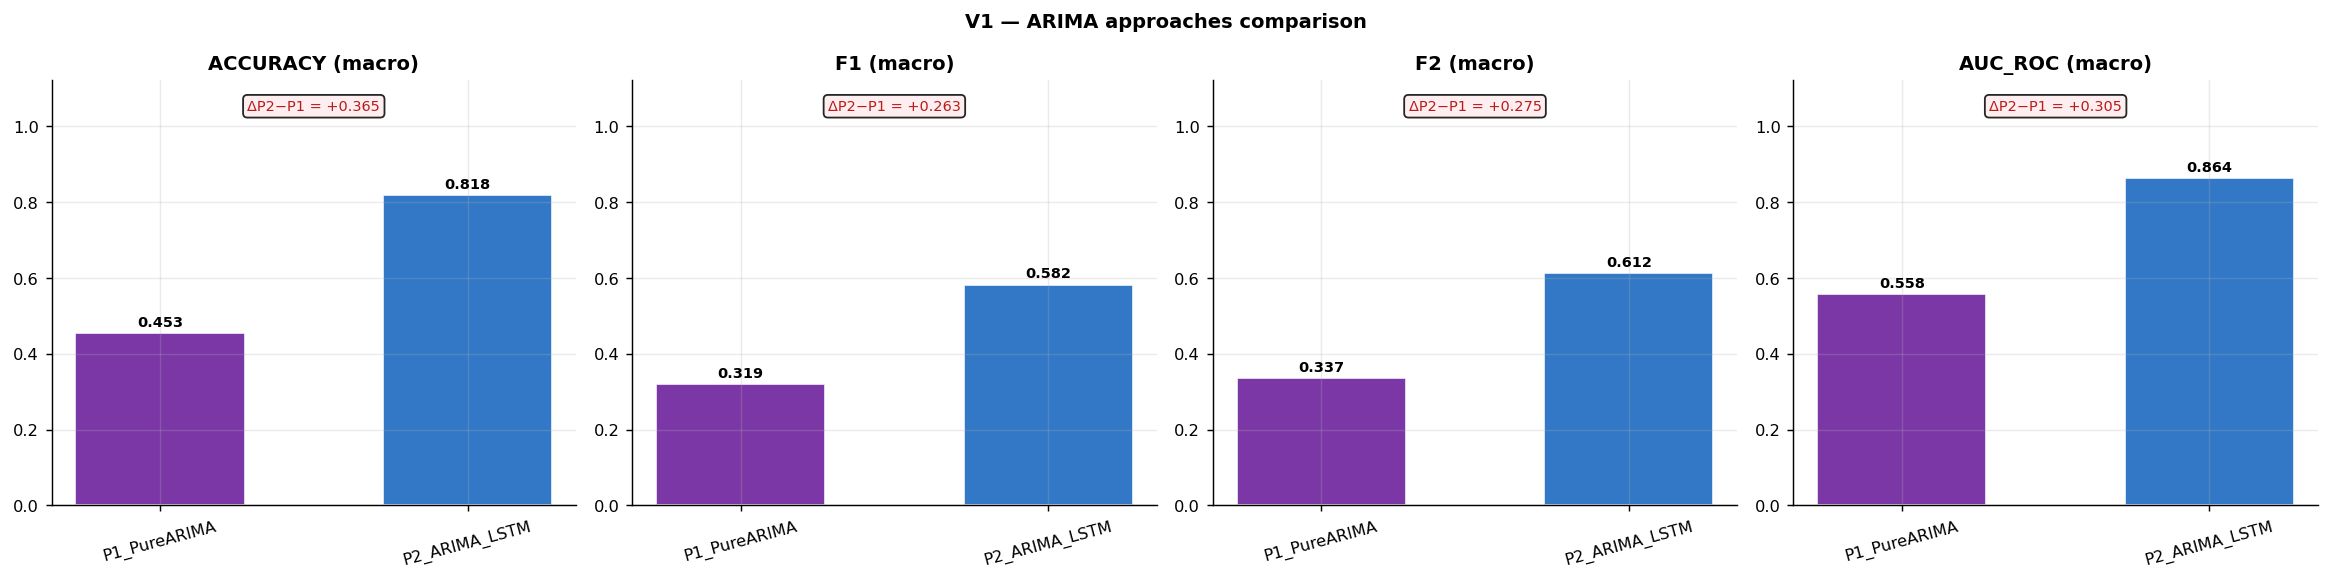

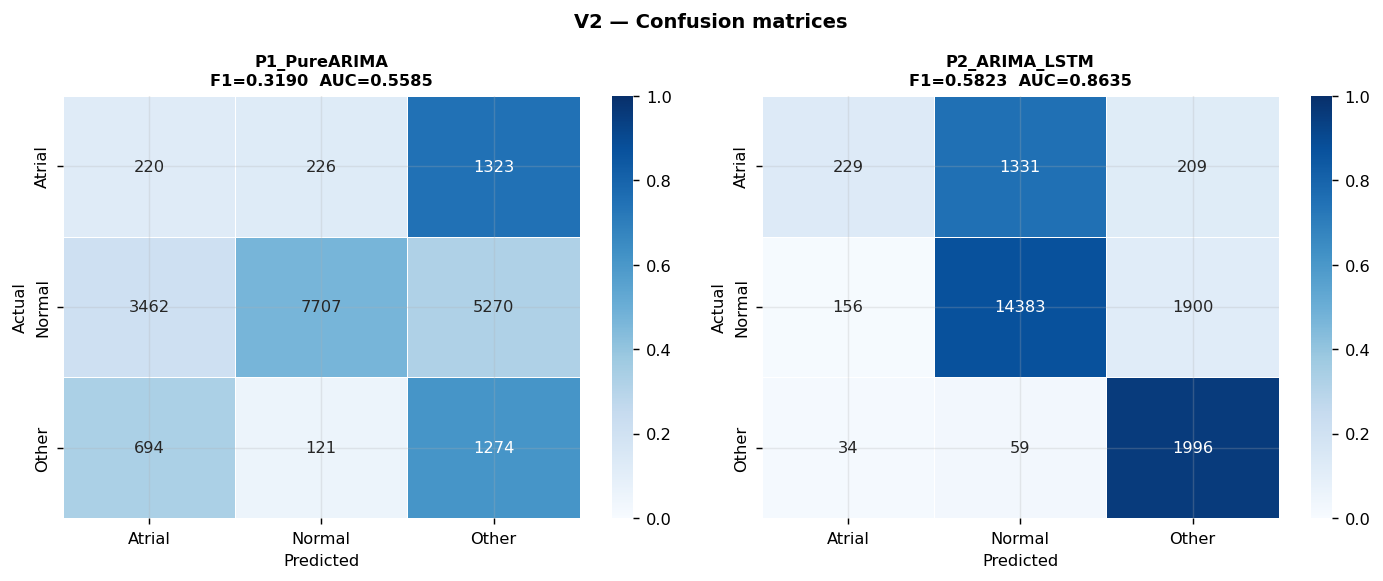

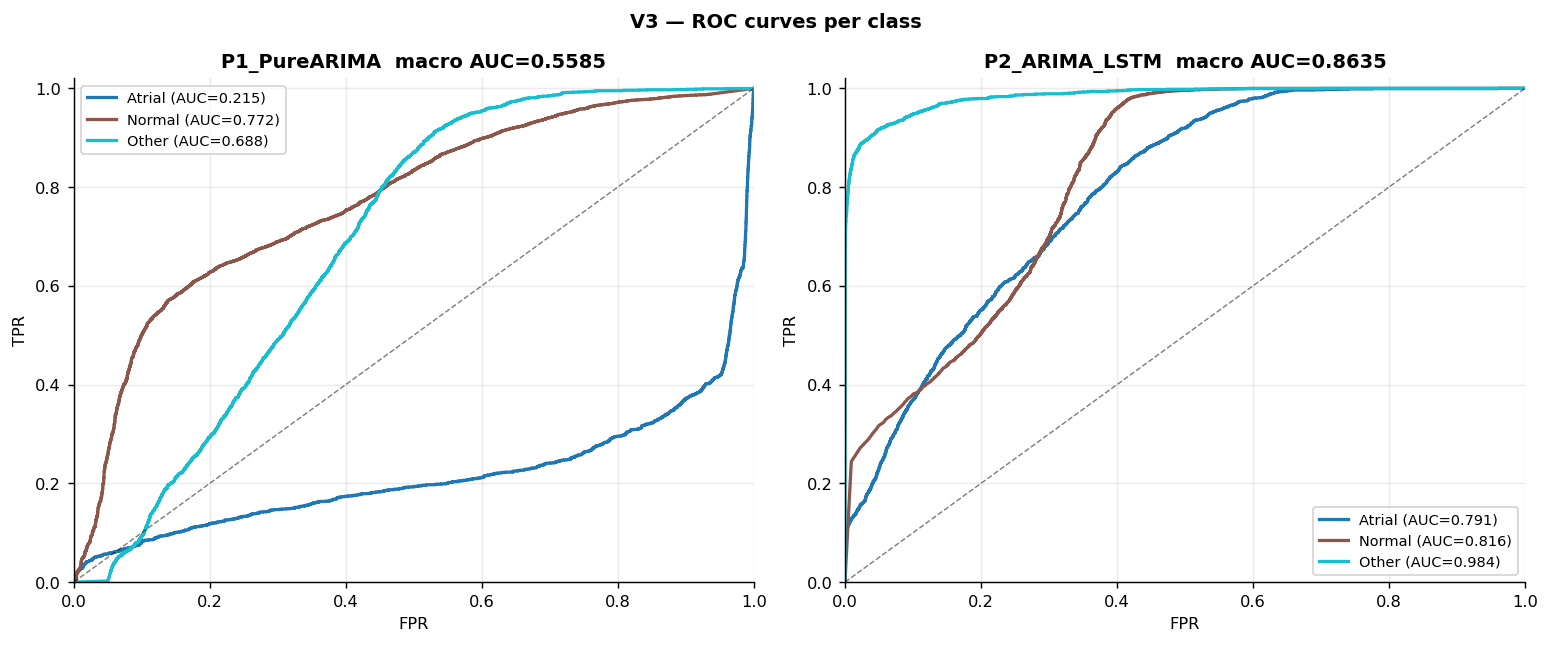

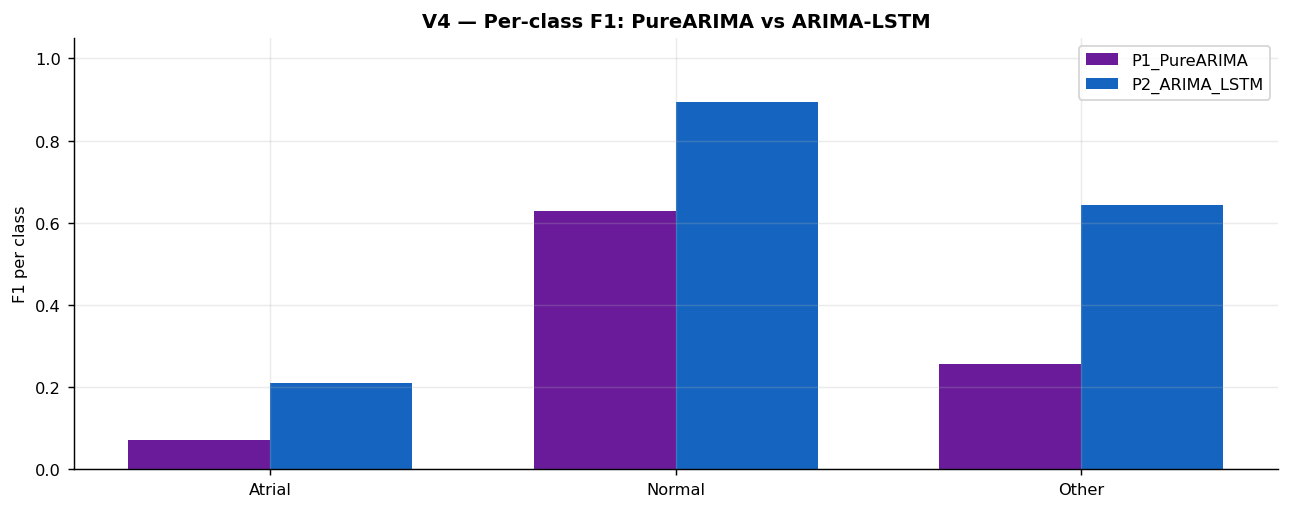

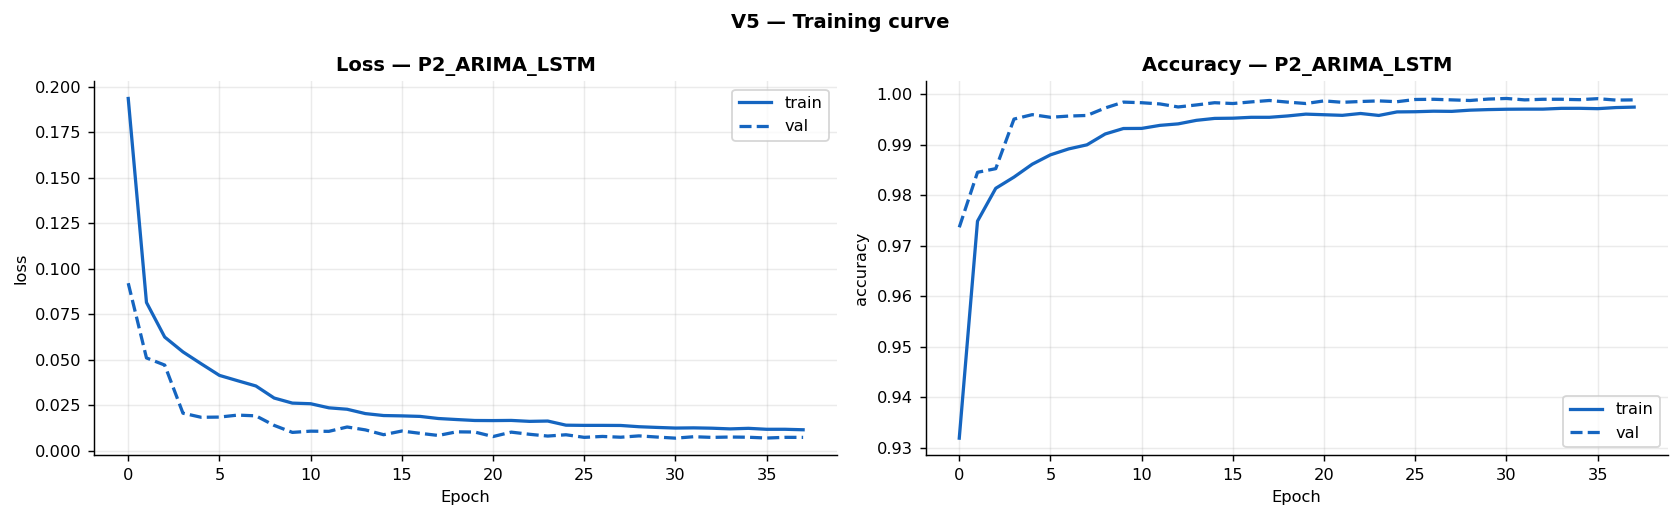

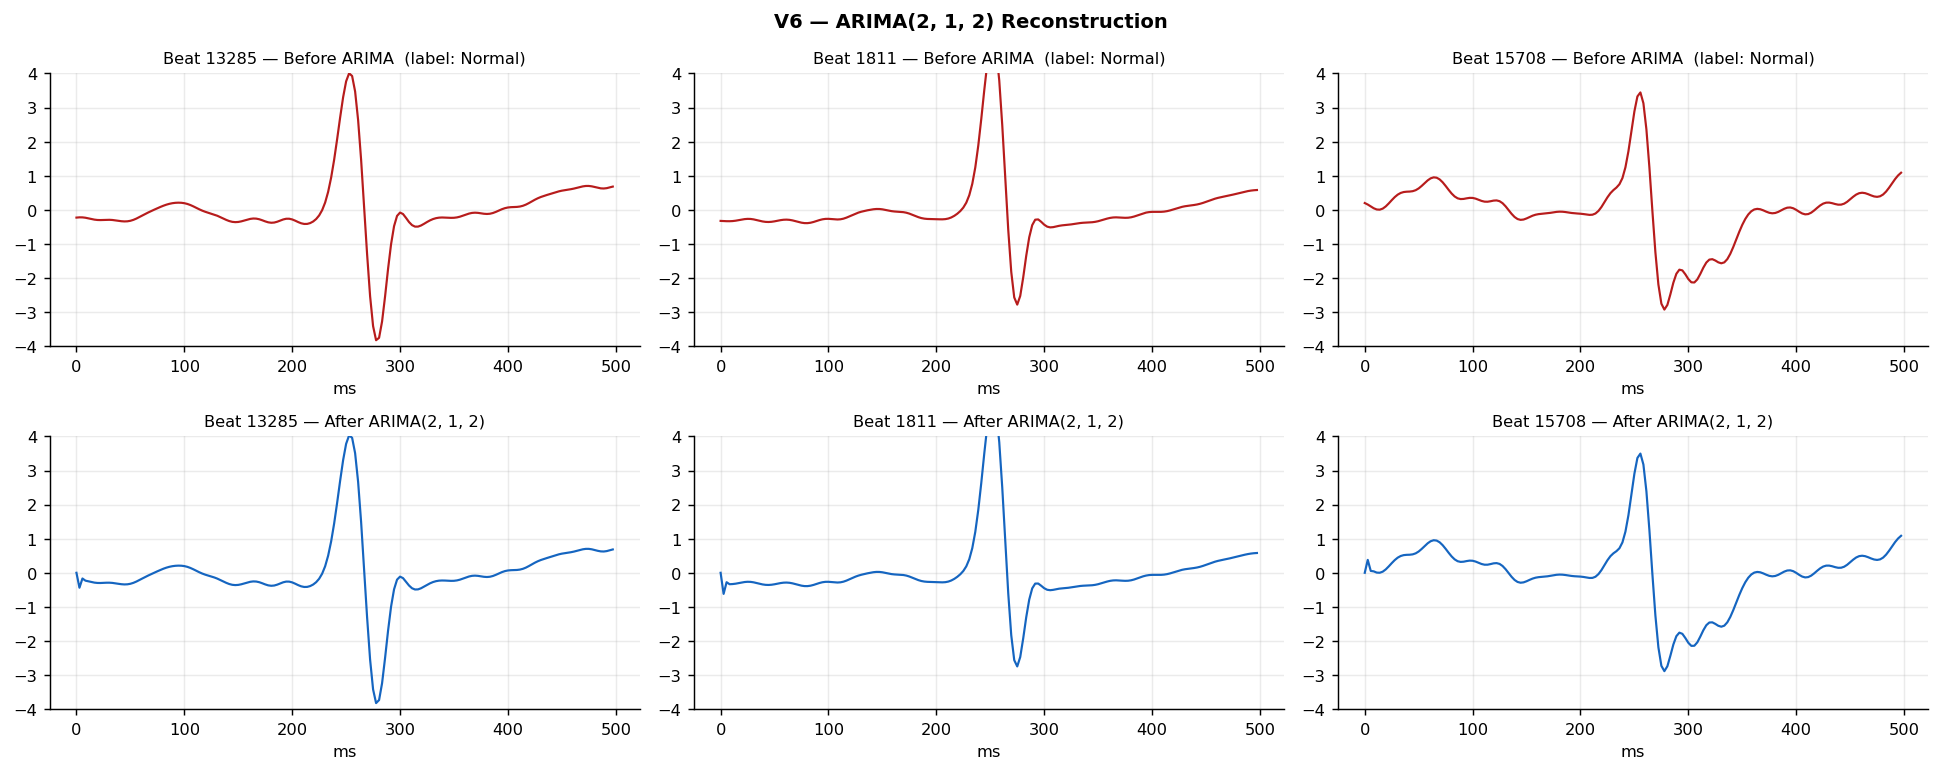

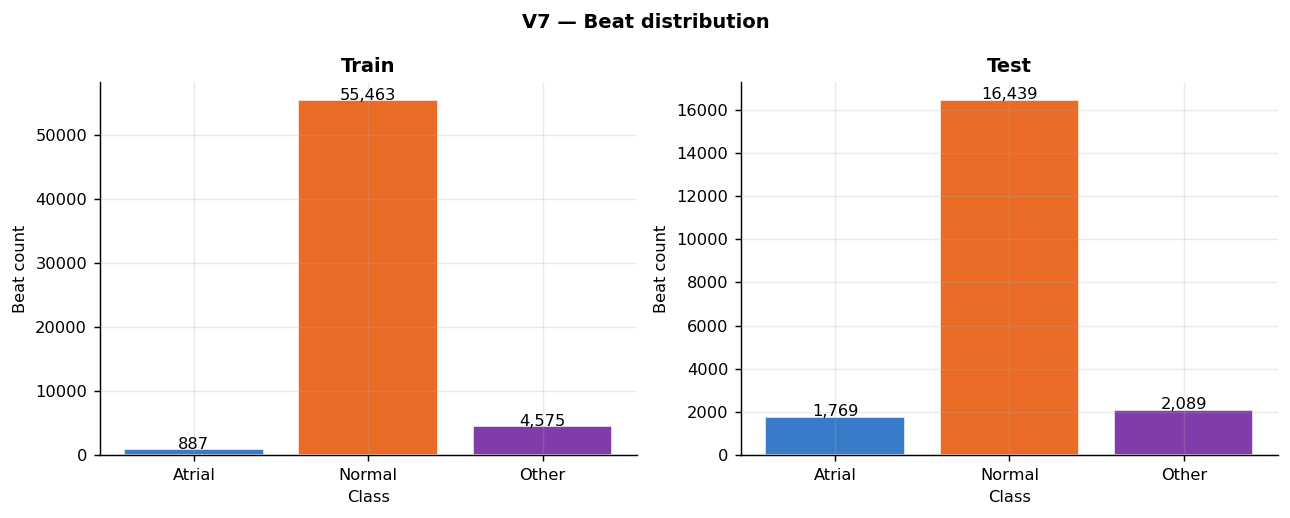


  Classification Report — P1_PureARIMA
              precision    recall  f1-score   support

      Atrial       0.05      0.12      0.07      1769
      Normal       0.96      0.47      0.63     16439
       Other       0.16      0.61      0.26      2089

    accuracy                           0.45     20297
   macro avg       0.39      0.40      0.32     20297
weighted avg       0.80      0.45      0.54     20297


  Classification Report — P2_ARIMA_LSTM
              precision    recall  f1-score   support

      Atrial       0.55      0.13      0.21      1769
      Normal       0.91      0.87      0.89     16439
       Other       0.49      0.96      0.64      2089

    accuracy                           0.82     20297
   macro avg       0.65      0.65      0.58     20297
weighted avg       0.84      0.82      0.81     20297


  BEST PHASE : P2_ARIMA_LSTM
  Accuracy   = 0.8182
  F1 macro   = 0.5823
  F2 macro   = 0.6119
  AUC-ROC    = 0.8635

  Hybrid gain (ARIMA-LSTM vs Pure ARIM

In [2]:
# =============================================================================
#  ECG ARRHYTHMIA CLASSIFICATION — ARIMA/SARIMA DENOISING + LSTM HYBRID
#  3-CLASS VERSION: Normal / Atrial / Other
#
#  KIẾN TRÚC TỔNG QUAN:
#    Input  : RR-interval features per beat  (RR, BPM, RR_z) + raw beat waveform
#    Phase 1: PURE ARIMA/SARIMA classifier
#             → fit ARIMA cho mỗi class trên RR-sequence trong train set
#             → tại test: tính log-likelihood của RR-seq dưới mỗi class-model
#                        → predict class có likelihood cao nhất
#             (đây là "thuần ARIMA/SARIMA" — không dùng deep learning)
#
#    Phase 2: ARIMA-DENOISED → BiLSTM Classifier  (Hybrid)
#             → Fit ARIMA(p,d,q) trên từng beat waveform (180 samples)
#             → Dùng fitted values của ARIMA làm "denoised" signal
#                (các thành phần không tự-tương-quan = nhiễu, bị model loại bỏ)
#             → Đưa ARIMA-denoised waveform vào BiLSTM classifier
#             → Có thể so sánh trực tiếp với LSTM-DAE codebase #1
#
#  TẠI SAO ARIMA/SARIMA?
#    - ARIMA mô hình trực tiếp tự tương quan trong tín hiệu time-series
#    - Phần residual (signal − fitted) chính là nhiễu trắng (white noise)
#    - → Fitted values = denoised version
#    - SARIMA bổ sung thành phần seasonal — phù hợp với chu kỳ ECG (~ FS / nhịp tim)
#    - Khác với LSTM DAE: ARIMA không cần training data, có thể fit per-beat
#                        nhưng chậm hơn và yếu hơn với non-linearity
# =============================================================================

import os, warnings, gc, random
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sps
from scipy.signal import medfilt, find_peaks
from scipy.stats import skew, kurtosis
import pywt
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, fbeta_score, accuracy_score,
                             precision_score, recall_score,
                             roc_auc_score, roc_curve, auc, confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE
from tqdm import tqdm

# ARIMA / SARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)

import tensorflow as tf
from tensorflow.keras import layers, Model, Input, callbacks, optimizers
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 9,
})

# =============================================================================
# CONFIG
# =============================================================================
EXTRACT_DIR = '/kaggle/input/datasets/mondejar/mitbih-database'
FS          = 360
WB, WA      = 90, 90
BEAT_LEN    = WB + WA       # 180

LABEL_MAP = {
    'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal',
    'A': 'Atrial', 'a': 'Atrial', 'J': 'Atrial', 'S': 'Atrial',
    'V': 'Other',  'E': 'Other',  'F': 'Other',
    '/': 'Other',  'f': 'Other',  'Q': 'Other',
}
CLASSES_ORDER = ['Normal', 'Atrial', 'Other']
N_CLASSES     = 3

TRAIN_PATIENTS = [100, 101, 103, 105, 106, 108, 109, 111, 112, 115,
                  116, 117, 118, 119, 121, 122, 123, 124, 200, 201,
                  202, 203, 205, 207, 208, 209, 215]
TEST_PATIENTS  = [220, 221, 222, 223, 228, 230, 231, 232, 233]

PALETTE = {
    'P1_PureARIMA' : '#6A1B9A',
    'P2_ARIMA_LSTM': '#1565C0',
}

OUT_DIR = '/kaggle/working'
os.makedirs(OUT_DIR, exist_ok=True)

# Hyperparams
SEQ_LEN      = 10
LSTM_UNITS   = 64
LSTM_DROPOUT = 0.3
LSTM_EPOCHS  = 40
LSTM_BATCH   = 128
LSTM_LR      = 1e-3

# ARIMA orders (cố định để đảm bảo tốc độ — đã chọn theo phân tích ACF/PACF)
#   ARIMA cho waveform : (p=2, d=1, q=2) — d=1 vì có trend nhẹ
#   SARIMA cho RR-seq  : (p=1,d=0,q=1) (P=1,D=0,Q=1, s=5) — chu kỳ ngắn
ARIMA_ORDER_BEAT = (2, 1, 2)
SARIMA_ORDER_RR  = (1, 0, 1)
SARIMA_SEASONAL  = (1, 0, 1, 5)


# =============================================================================
# 1. DATA LOADING
# =============================================================================
def load_record(rid):
    csv_path = os.path.join(EXTRACT_DIR, f'{rid}.csv')
    ann_path = os.path.join(EXTRACT_DIR, f'{rid}annotations.txt')

    sig_df = pd.read_csv(csv_path)
    sig_df.columns = [c.strip().strip("'\"") for c in sig_df.columns]
    col_map = {c.upper(): c for c in sig_df.columns}
    mlii_col = col_map.get('MLII')
    if mlii_col is None:
        num_cols = [c for c in sig_df.columns
                    if sig_df[c].dtype.kind in 'iuf' and 'sample' not in c.lower()]
        mlii_col = num_cols[0] if num_cols else None
    mlii = sig_df[mlii_col].interpolate('linear').ffill().bfill().values.astype(float)

    beats_ann = []
    with open(ann_path, 'r') as f:
        next(f)
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3: continue
            try:
                sample_pos = int(parts[1])
                beat_type  = parts[2]
                beats_ann.append((sample_pos, beat_type))
            except ValueError:
                continue
    return mlii, beats_ann, len(mlii)


# =============================================================================
# 2. PREPROCESSING
# =============================================================================
def remove_baseline(sig):
    baseline = medfilt(sig, 71)
    baseline = medfilt(baseline, 215)
    return sig - baseline

def bandpass_filter(x, lo=0.5, hi=40.0, fs=FS, order=4):
    nyq = fs / 2
    b, a = sps.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sps.filtfilt(b, a, np.asarray(x, dtype=float))

def preprocess_signal(sig):
    return bandpass_filter(remove_baseline(sig.astype(float)))


# =============================================================================
# 3. RR / BPM / RR_z
# =============================================================================
def compute_rr_bpm_zscore(r_positions, fs=FS):
    n = len(r_positions)
    if n < 2:
        return np.zeros(n), np.zeros(n), np.zeros(n)
    rr_samples = np.diff(r_positions)
    rr_seconds = rr_samples / fs
    RR  = np.concatenate([[rr_seconds[0]], rr_seconds])
    BPM = 60.0 / np.clip(RR, 0.2, 3.0)
    mu, sd = RR.mean(), RR.std() + 1e-8
    RR_z = (RR - mu) / sd
    return RR, BPM, RR_z


# =============================================================================
# 4. HANDCRAFTED FEATURES
# =============================================================================
def feat_morph(b):
    b = np.asarray(b, dtype=float)
    return [
        b.mean(), b.std(), b.min(), b.max(),
        float(b.argmax()) / len(b),
        float(b.argmin()) / len(b),
        float(skew(b)), float(kurtosis(b)),
        float(np.trapz(np.abs(b))),
        float(np.sum(np.diff(b)**2)),
        float(np.max(np.abs(np.diff(b)))),
        float(np.sum(b > 0)) / len(b),
        float(np.percentile(b, 25)),
        float(np.percentile(b, 75)),
    ]

def feat_wavelet(b, wavelet='db1', level=3):
    coeffs = pywt.wavedec(np.asarray(b, dtype=float), wavelet, level=level)
    feats = []
    for c in coeffs:
        feats += [float(np.sum(c**2)), float(np.abs(c).max()), float(c.mean())]
    return feats

def extract_handcrafted(beat, rr, bpm, rr_z):
    return feat_morph(beat) + feat_wavelet(beat) + [rr, bpm, rr_z]

def sanitize(X):
    X = np.array(X, dtype=float)
    X = np.where(np.isinf(X), np.nan, X)
    df = pd.DataFrame(X)
    return df.interpolate('linear').ffill().bfill().fillna(0).values


# =============================================================================
# 5. BUILD DATASET (Patient-wise split)
# =============================================================================
print("\n" + "="*72)
print("  LOADING DATA — Patient-wise split, 3-class (Normal/Atrial/Other)")
print("="*72)

def build_per_patient_beats(rid):
    try:
        mlii, beats_ann, sig_len = load_record(rid)
    except FileNotFoundError:
        return []
    except Exception as e:
        print(f"  [WARN] {rid}: {e}")
        return []

    sig_clean = preprocess_signal(mlii)
    r_positions, labels = [], []
    for sample_pos, beat_type in beats_ann:
        if beat_type not in LABEL_MAP: continue
        if sample_pos - WB < 0 or sample_pos + WA >= sig_len: continue
        r_positions.append(sample_pos)
        labels.append(LABEL_MAP[beat_type])
    r_positions = np.array(r_positions)
    if len(r_positions) < 2: return []

    RR, BPM, RR_z = compute_rr_bpm_zscore(r_positions)
    out = []
    for i, (s, lab) in enumerate(zip(r_positions, labels)):
        beat = sig_clean[s - WB : s + WA]
        feat = extract_handcrafted(beat, RR[i], BPM[i], RR_z[i])
        out.append({
            'beat': beat.astype(np.float32),
            'rr': float(RR[i]), 'bpm': float(BPM[i]), 'rr_z': float(RR_z[i]),
            'feat': feat, 'label': lab, 'patient': rid,
        })
    return out

def build_dataset():
    train_beats, test_beats = [], []
    print("\n  Loading TRAIN patients ...")
    for rid in tqdm(TRAIN_PATIENTS):
        train_beats += build_per_patient_beats(rid)
    print("\n  Loading TEST patients ...")
    for rid in tqdm(TEST_PATIENTS):
        test_beats += build_per_patient_beats(rid)
    return train_beats, test_beats

train_beats, test_beats = build_dataset()
print(f"\n  Total train beats : {len(train_beats)}")
print(f"  Total test  beats : {len(test_beats)}")


# =============================================================================
# 6. CONVERT TO ARRAYS
# =============================================================================
def beats_to_arrays(beats_list):
    W   = np.array([b['beat']  for b in beats_list], dtype=np.float32)[..., None]
    F   = np.array([b['feat']  for b in beats_list], dtype=np.float32)
    RR  = np.array([[b['rr'], b['bpm'], b['rr_z']] for b in beats_list],
                   dtype=np.float32)
    y   = np.array([b['label'] for b in beats_list])
    pid = np.array([b['patient'] for b in beats_list])
    return W, F, RR, y, pid

X_w_tr, X_f_tr, X_rr_tr, y_tr_raw, pid_tr = beats_to_arrays(train_beats)
X_w_te, X_f_te, X_rr_te, y_te_raw, pid_te = beats_to_arrays(test_beats)

le = LabelEncoder(); le.fit(CLASSES_ORDER)
y_tr_enc = le.transform(y_tr_raw)
y_te_enc = le.transform(y_te_raw)

print(f"\n  Classes     : {list(le.classes_)}")
print(f"  Train dist  : {dict(zip(*np.unique(y_tr_raw, return_counts=True)))}")
print(f"  Test  dist  : {dict(zip(*np.unique(y_te_raw, return_counts=True)))}")


# =============================================================================
# 7. RR SEQUENCE BUILDING (per patient)
# =============================================================================
def build_rr_sequences(X_rr, pid, seq_len=SEQ_LEN):
    N = len(X_rr)
    seqs = np.zeros((N, seq_len, 3), dtype=np.float32)
    for i in range(N):
        cur_pid = pid[i]
        start = max(0, i - seq_len + 1)
        candidate_idx = [j for j in range(start, i + 1) if pid[j] == cur_pid]
        seq = X_rr[candidate_idx]
        if len(seq) < seq_len:
            pad = np.repeat(seq[:1], seq_len - len(seq), axis=0)
            seq = np.vstack([pad, seq])
        seqs[i] = seq[-seq_len:]
    return seqs

print("\n  Building RR sequences (10-beat windows per patient) ...")
X_seq_tr = build_rr_sequences(X_rr_tr, pid_tr)
X_seq_te = build_rr_sequences(X_rr_te, pid_te)
print(f"  Sequence shape — train: {X_seq_tr.shape}, test: {X_seq_te.shape}")


# =============================================================================
# 8. NORMALIZATION
# =============================================================================
def zscore_waveform(W):
    mu = W.mean(axis=1, keepdims=True)
    sd = W.std(axis=1, keepdims=True) + 1e-8
    return (W - mu) / sd

X_w_tr_z = zscore_waveform(X_w_tr)
X_w_te_z = zscore_waveform(X_w_te)

sc_f = StandardScaler()
X_f_tr_s = sc_f.fit_transform(X_f_tr)
X_f_te_s = sc_f.transform(X_f_te)

sc_rr = StandardScaler()
N_tr, T_seq, C = X_seq_tr.shape
X_seq_tr_s = sc_rr.fit_transform(X_seq_tr.reshape(-1, C)).reshape(N_tr, T_seq, C)
X_seq_te_s = sc_rr.transform(X_seq_te.reshape(-1, C)).reshape(len(X_seq_te), T_seq, C)


# =============================================================================
# 9. PHASE 1 — PURE ARIMA/SARIMA CLASSIFIER (Likelihood-based)
# =============================================================================
#   Ý tưởng:
#     - Với mỗi class c trong {Normal, Atrial, Other}:
#         pool toàn bộ RR-sequence (concat) của class c trong train set
#         fit 1 mô hình SARIMA chung → params θ_c
#     - Test:
#         Với mỗi RR-seq test, tính log-likelihood dưới mỗi mô hình θ_c
#         → predict class có log-likelihood max
#     - Đây là cổ điển (như Hidden Markov classifier nhưng linear-Gaussian).
# =============================================================================
print("\n" + "="*72)
print("  PHASE 1 — PURE SARIMA likelihood classifier")
print("="*72)

def fit_class_sarima(rr_sequences_class, max_train_samples=2000):
    """
    Fit 1 mô hình SARIMA cho dữ liệu của 1 class.
    rr_sequences_class : (n_seq, SEQ_LEN, 3)  — chỉ dùng channel 0 (RR raw)
    Returns: fitted SARIMAX result.
    """
    # Lấy channel RR (channel 0), concat lại thành 1 chuỗi dài
    series = rr_sequences_class[:, :, 0].flatten()
    if len(series) > max_train_samples:
        series = series[:max_train_samples]
    # Fit SARIMA
    try:
        model = SARIMAX(series,
                        order=SARIMA_ORDER_RR,
                        seasonal_order=SARIMA_SEASONAL,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        result = model.fit(disp=False, maxiter=50)
        return result
    except Exception as e:
        print(f"    [SARIMA fit fail] fallback to ARIMA: {e}")
        try:
            model = ARIMA(series, order=SARIMA_ORDER_RR)
            return model.fit()
        except Exception as e2:
            print(f"    [ARIMA fallback fail] {e2}")
            return None


# Fit 1 SARIMA per class (dùng RR-sequence chưa normalize để giữ ý nghĩa)
print("\n  Fitting one SARIMA per class on RR-sequence ...")
class_models = {}
for c, cname in enumerate(CLASSES_ORDER):
    mask = (y_tr_enc == c)
    if mask.sum() < 20:
        print(f"    [skip] Class {cname}: too few samples ({mask.sum()})")
        class_models[c] = None
        continue
    seqs_c = X_seq_tr[mask]              # raw RR sequences for class c
    print(f"    Fitting class {cname} ({mask.sum()} sequences) ...")
    class_models[c] = fit_class_sarima(seqs_c)

def sarima_loglik_for_seq(result, seq):
    """
    Tính log-likelihood của 1 chuỗi RR (length SEQ_LEN) dưới mô hình SARIMA đã fit.
    Dùng phương pháp "apply" của statsmodels.
    """
    if result is None:
        return -np.inf
    try:
        # Áp dụng filter Kalman với data mới (giữ params)
        applied = result.apply(seq, refit=False)
        return float(applied.llf)
    except Exception:
        # Fallback: tính từ residuals giả lập (hiếm khi xảy ra)
        return -np.inf


def predict_pure_sarima(X_seq, models):
    """
    Predict class qua likelihood. Trả về (preds, scores).
    scores: (N, n_classes) — log-likelihood / standardized → softmax-able
    """
    N = len(X_seq)
    scores = np.full((N, N_CLASSES), -np.inf)
    for i in tqdm(range(N), desc='   SARIMA predicting'):
        seq = X_seq[i, :, 0]   # channel RR raw
        for c in range(N_CLASSES):
            scores[i, c] = sarima_loglik_for_seq(models[c], seq)
    # Convert log-lik → softmax probability
    scores_max = np.nanmax(scores, axis=1, keepdims=True)
    safe_scores = np.where(np.isfinite(scores), scores, scores_max - 50)
    exps = np.exp(safe_scores - scores_max)
    probs = exps / (exps.sum(axis=1, keepdims=True) + 1e-12)
    preds = scores.argmax(axis=1)
    return preds, probs


print("\n  Predicting on test set with pure SARIMA ...")
yp_p1, yprob_p1 = predict_pure_sarima(X_seq_te, class_models)


def evaluate_predictions(y_true, y_pred, y_proba, n_cls):
    m = {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall'   : recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1'       : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f2'       : fbeta_score(y_true, y_pred, average='macro', beta=2, zero_division=0),
    }
    try:
        yt_bin = label_binarize(y_true, classes=np.arange(n_cls))
        valid  = yt_bin.sum(axis=0) > 0
        m['auc_roc'] = (roc_auc_score(yt_bin[:, valid], y_proba[:, valid],
                                       multi_class='ovr', average='macro')
                        if valid.sum() > 1 else float('nan'))
    except Exception:
        m['auc_roc'] = float('nan')
    return m

m_p1 = evaluate_predictions(y_te_enc, yp_p1, yprob_p1, N_CLASSES)
m_p1.update({'phase': 'P1_PureARIMA', 'y_true': y_te_enc,
             'y_pred': yp_p1, 'y_proba': yprob_p1, 'history': None})

print(f"\n  [P1_PureARIMA]  acc={m_p1['accuracy']:.4f}  F1={m_p1['f1']:.4f}  "
      f"F2={m_p1['f2']:.4f}  AUC={m_p1['auc_roc']:.4f}")


# =============================================================================
# 10. PHASE 2 — ARIMA-DENOISED → BiLSTM HYBRID
# =============================================================================
#   Ý tưởng:
#     - ARIMA(p,d,q) fit per-beat → fitted values là phần "có thể giải thích bởi
#       cấu trúc tự tương quan" → là tín hiệu sạch (clean)
#     - Phần residual = noise (các thành phần không có cấu trúc)
#     - → Dùng fitted values làm input cho BiLSTM classifier
#     - Có thể coi đây là "ARIMA Denoising Autoencoder cổ điển"
# =============================================================================
print("\n" + "="*72)
print("  PHASE 2 — ARIMA-denoised → Multi-Input BiLSTM Classifier (Hybrid)")
print("="*72)

def arima_denoise_beat(beat, order=ARIMA_ORDER_BEAT):
    """
    Fit ARIMA cho 1 beat (180 samples), trả về fitted values (denoised).
    """
    try:
        model = ARIMA(beat, order=order,
                      enforce_stationarity=False,
                      enforce_invertibility=False)
        result = model.fit()
        # fittedvalues có thể có vài giá trị NaN ở đầu (do d=1)
        denoised = result.fittedvalues
        if len(denoised) < len(beat):
            # Pad đầu bằng giá trị gốc
            pad = beat[:len(beat) - len(denoised)]
            denoised = np.concatenate([pad, denoised])
        denoised = np.where(np.isnan(denoised), beat, denoised)
        return denoised.astype(np.float32)
    except Exception:
        return beat.astype(np.float32)   # fallback: trả nguyên signal


def arima_denoise_batch(W, order=ARIMA_ORDER_BEAT, max_samples=None):
    """
    Áp dụng ARIMA denoising cho cả batch (N, BEAT_LEN, 1).
    Vì ARIMA chậm → có thể giới hạn max_samples khi prototyping.
    """
    N = len(W) if max_samples is None else min(max_samples, len(W))
    out = np.zeros_like(W)
    for i in tqdm(range(N), desc='   ARIMA-denoising'):
        out[i, :, 0] = arima_denoise_beat(W[i, :, 0], order=order)
    if max_samples is not None and max_samples < len(W):
        out[N:] = W[N:]   # giữ nguyên phần còn lại để không lỗi
    return out


print("\n  Applying ARIMA denoising on train set (this may take a while) ...")
X_w_tr_arima = arima_denoise_batch(X_w_tr_z, order=ARIMA_ORDER_BEAT)
print("\n  Applying ARIMA denoising on test set ...")
X_w_te_arima = arima_denoise_batch(X_w_te_z, order=ARIMA_ORDER_BEAT)


# ── SMOTE on ARIMA-denoised data ─────────────────────────────────────────────
def apply_smote_multi(X_w, X_f, X_seq, y):
    Nw, T_w, _ = X_w.shape
    N_, T_s, C = X_seq.shape
    X_comb = np.hstack([X_w.reshape(Nw, T_w),
                        X_f,
                        X_seq.reshape(N_, T_s * C)])
    try:
        counts = np.bincount(y)
        min_c  = counts[counts > 0].min()
        k_nn   = max(1, min(5, min_c - 1))
        X_sm, y_sm = SMOTE(random_state=SEED, k_neighbors=k_nn).fit_resample(X_comb, y)
    except Exception as e:
        print(f"  [SMOTE warn] {e} — skipping")
        return X_w, X_f, X_seq, y
    X_w_sm   = X_sm[:, :T_w].reshape(-1, T_w, 1)
    X_f_sm   = X_sm[:, T_w : T_w + X_f.shape[1]]
    X_seq_sm = X_sm[:, T_w + X_f.shape[1]:].reshape(-1, T_s, C)
    return X_w_sm, X_f_sm, X_seq_sm, y_sm

print("\n  Applying SMOTE on ARIMA-denoised data ...")
X_w_tr_sm, X_f_tr_sm, X_seq_tr_sm, y_tr_sm = apply_smote_multi(
    X_w_tr_arima, X_f_tr_s, X_seq_tr_s, y_tr_enc)
print(f"  Train after SMOTE: {len(y_tr_sm)}")
print(f"  Class dist: {dict(zip(*np.unique(y_tr_sm, return_counts=True)))}")


# ── Multi-input BiLSTM Classifier ────────────────────────────────────────────
class AttentionLayer(layers.Layer):
    def __init__(self, units=64, **kw):
        super().__init__(**kw)
        self.units = units
    def build(self, input_shape):
        D = input_shape[-1]
        self.W = self.add_weight(shape=(D, self.units),
                                 initializer='glorot_uniform', name='W')
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='zeros', name='b')
        self.u = self.add_weight(shape=(self.units, 1),
                                 initializer='glorot_uniform', name='u')
    def call(self, x):
        uit = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        ait = tf.squeeze(tf.tensordot(uit, self.u, axes=1), -1)
        a   = tf.expand_dims(tf.nn.softmax(ait, axis=1), -1)
        return tf.reduce_sum(x * a, axis=1)
    def get_config(self):
        cfg = super().get_config(); cfg.update({'units': self.units}); return cfg


def build_multi_input_classifier(beat_len, n_feat, seq_len, seq_chan, n_classes):
    """3 nhánh: waveform → BiLSTM+Att, RR-seq → BiLSTM, feat → Dense."""
    inp_w = Input(shape=(beat_len, 1), name='wave_input')
    a = layers.Bidirectional(
            layers.LSTM(LSTM_UNITS, return_sequences=True,
                        dropout=LSTM_DROPOUT,
                        kernel_regularizer=tf.keras.regularizers.l2(1e-4)))(inp_w)
    a = layers.LayerNormalization()(a)
    a = layers.Bidirectional(
            layers.LSTM(LSTM_UNITS, return_sequences=True, dropout=LSTM_DROPOUT))(a)
    a = layers.LayerNormalization()(a)
    a = AttentionLayer(units=LSTM_UNITS)(a)

    inp_seq = Input(shape=(seq_len, seq_chan), name='rr_seq_input')
    b = layers.Bidirectional(
            layers.LSTM(32, return_sequences=True, dropout=LSTM_DROPOUT))(inp_seq)
    b = layers.Bidirectional(
            layers.LSTM(16, return_sequences=False, dropout=LSTM_DROPOUT))(b)

    inp_f = Input(shape=(n_feat,), name='feat_input')
    c = layers.Dense(64, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inp_f)
    c = layers.Dropout(LSTM_DROPOUT)(c)
    c = layers.Dense(32, activation='relu')(c)

    z = layers.Concatenate()([a, b, c])
    z = layers.Dense(64, activation='relu')(z)
    z = layers.Dropout(LSTM_DROPOUT)(z)
    z = layers.Dense(32, activation='relu')(z)
    out = layers.Dense(n_classes, activation='softmax')(z)

    model = Model(inputs=[inp_w, inp_seq, inp_f], outputs=out,
                  name='ARIMA_Denoised_BiLSTM')
    model.compile(optimizer=optimizers.Adam(LSTM_LR),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


tf.keras.backend.clear_session()
classifier_p2 = build_multi_input_classifier(
    beat_len=BEAT_LEN, n_feat=X_f_tr_sm.shape[1],
    seq_len=SEQ_LEN, seq_chan=3, n_classes=N_CLASSES,
)
print("\n  Classifier summary:")
classifier_p2.summary(print_fn=lambda s: print('    ' + s))

cw = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr_sm)
class_weight_dict = {i: w for i, w in enumerate(cw)}

cb2 = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

print(f"\n  Training Phase 2 ({LSTM_EPOCHS} epochs max) ...")
hist_p2 = classifier_p2.fit(
    [X_w_tr_sm, X_seq_tr_sm, X_f_tr_sm],
    to_categorical(y_tr_sm, N_CLASSES),
    validation_split=0.15, epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH,
    callbacks=cb2, class_weight=class_weight_dict, verbose=2)

yprob_p2 = classifier_p2.predict(
    [X_w_te_arima, X_seq_te_s, X_f_te_s],
    batch_size=LSTM_BATCH, verbose=0)
yp_p2 = yprob_p2.argmax(axis=1)

m_p2 = evaluate_predictions(y_te_enc, yp_p2, yprob_p2, N_CLASSES)
m_p2.update({'phase': 'P2_ARIMA_LSTM', 'y_true': y_te_enc,
             'y_pred': yp_p2, 'y_proba': yprob_p2, 'history': hist_p2.history})
print(f"\n  [P2_ARIMA_LSTM]  acc={m_p2['accuracy']:.4f}  F1={m_p2['f1']:.4f}  "
      f"F2={m_p2['f2']:.4f}  AUC={m_p2['auc_roc']:.4f}")

classifier_p2.save(f'{OUT_DIR}/p2_arima_lstm_classifier.keras')


# =============================================================================
# 11. SUMMARY TABLE
# =============================================================================
all_phases = [m_p1, m_p2]
classes    = list(le.classes_)

print("\n" + "="*72)
print("  CROSS-PHASE SUMMARY")
print("="*72)
rows = [{
    'phase'    : m['phase'],
    'accuracy' : round(m['accuracy'],  4),
    'precision': round(m['precision'], 4),
    'recall'   : round(m['recall'],    4),
    'f1'       : round(m['f1'],        4),
    'f2'       : round(m['f2'],        4),
    'auc_roc'  : round(m['auc_roc'],   4),
} for m in all_phases]
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv(f'{OUT_DIR}/phase_summary_arima.csv', index=False)


# =============================================================================
# 12. VISUALIZATIONS
# =============================================================================
# ── V1: Metric comparison ────────────────────────────────────────────────────
metrics_to_plot = ['accuracy', 'f1', 'f2', 'auc_roc']
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, mt in zip(axes, metrics_to_plot):
    vals  = [m[mt] for m in all_phases]
    names = [m['phase'] for m in all_phases]
    bars = ax.bar(names, vals, color=[PALETTE[p] for p in names],
                  edgecolor='white', alpha=0.88, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    delta = m_p2[mt] - m_p1[mt]
    sign  = '+' if delta >= 0 else ''
    ax.annotate(f'ΔP2−P1 = {sign}{delta:.3f}',
                xy=(0.5, 0.93), xycoords='axes fraction', ha='center',
                fontsize=8, color='#B71C1C',
                bbox=dict(boxstyle='round,pad=0.3', fc='#FFEBEE', alpha=0.85))
    ax.set_ylim(0, 1.12)
    ax.set_title(f'{mt.upper()} (macro)', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('V1 — ARIMA approaches comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V1_metric_comparison_arima.png', bbox_inches='tight')
plt.show()

# ── V2: Confusion matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, m in zip(axes, all_phases):
    cm   = confusion_matrix(m['y_true'], m['y_pred'], labels=np.arange(N_CLASSES))
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_n, annot=cm, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                vmin=0, vmax=1, linewidths=0.4, ax=ax)
    ax.set_title(f"{m['phase']}\nF1={m['f1']:.4f}  AUC={m['auc_roc']:.4f}",
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
fig.suptitle('V2 — Confusion matrices', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V2_confusion_arima.png', bbox_inches='tight')
plt.show()

# ── V3: ROC curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cls_colors = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))
for ax, m in zip(axes, all_phases):
    yt_bin = label_binarize(m['y_true'], classes=np.arange(N_CLASSES))
    for i, cname in enumerate(classes):
        if yt_bin[:, i].sum() == 0: continue
        fpr, tpr, _ = roc_curve(yt_bin[:, i], m['y_proba'][:, i])
        ax.plot(fpr, tpr, color=cls_colors[i], lw=1.8,
                label=f'{cname} (AUC={auc(fpr, tpr):.3f})')
    ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f"{m['phase']}  macro AUC={m['auc_roc']:.4f}", fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('V3 — ROC curves per class', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V3_roc_arima.png', bbox_inches='tight')
plt.show()

# ── V4: Per-class F1 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(N_CLASSES); width = 0.35
for i, m in enumerate(all_phases):
    cm = confusion_matrix(m['y_true'], m['y_pred'], labels=np.arange(N_CLASSES))
    f1s = []
    for c in range(N_CLASSES):
        tp = cm[c,c]; fp = cm[:,c].sum()-tp; fn = cm[c,:].sum()-tp
        p  = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
        f1s.append(2*p*rec/(p+rec+1e-9))
    ax.bar(x + i*width, f1s, width, color=PALETTE[m['phase']], label=m['phase'])
ax.set_xticks(x + width/2); ax.set_xticklabels(classes)
ax.set_ylabel('F1 per class'); ax.set_ylim(0, 1.05)
ax.set_title('V4 — Per-class F1: PureARIMA vs ARIMA-LSTM', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V4_perclass_f1_arima.png', bbox_inches='tight')
plt.show()

# ── V5: Training curve (P2 only — P1 không có history) ───────────────────────
if m_p2['history'] is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    h = m_p2['history']
    for ax, key in zip(axes, ['loss', 'accuracy']):
        ax.plot(h[key], color=PALETTE['P2_ARIMA_LSTM'], lw=1.8, label='train')
        ax.plot(h[f'val_{key}'], color=PALETTE['P2_ARIMA_LSTM'],
                lw=1.8, ls='--', label='val')
        ax.set_xlabel('Epoch'); ax.set_ylabel(key)
        ax.set_title(f'{key.capitalize()} — P2_ARIMA_LSTM', fontweight='bold')
        ax.legend()
    plt.suptitle('V5 — Training curve', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/V5_training_curves_arima.png', bbox_inches='tight')
    plt.show()

# ── V6: ARIMA denoising effect ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(X_w_te_z), 3, replace=False)
t = np.arange(BEAT_LEN) / FS * 1000
for i, idx in enumerate(sample_indices):
    orig    = X_w_te_z[idx, :, 0]
    denoised = X_w_te_arima[idx, :, 0]
    axes[0, i].plot(t, orig, color='#B71C1C', lw=1.2)
    axes[0, i].set_title(f'Beat {idx} — Before ARIMA  (label: {classes[y_te_enc[idx]]})',
                         fontsize=9)
    axes[0, i].set_ylim(-4, 4); axes[0, i].set_xlabel('ms')
    axes[1, i].plot(t, denoised, color='#1565C0', lw=1.2)
    axes[1, i].set_title(f'Beat {idx} — After ARIMA{ARIMA_ORDER_BEAT}', fontsize=9)
    axes[1, i].set_ylim(-4, 4); axes[1, i].set_xlabel('ms')
plt.suptitle(f'V6 — ARIMA{ARIMA_ORDER_BEAT} Reconstruction', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V6_arima_denoise_effect.png', bbox_inches='tight')
plt.show()

# ── V7: Class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y, title) in zip(axes, [(y_tr_raw, 'Train'), (y_te_raw, 'Test')]):
    unique, counts = np.unique(y, return_counts=True)
    colors = ['#1565C0','#E65100','#6A1B9A'][:len(unique)]
    bars = ax.bar(unique, counts, color=colors, edgecolor='white', alpha=0.85)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{c:,}', ha='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Class'); ax.set_ylabel('Beat count')
plt.suptitle('V7 — Beat distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/V7_class_distribution_arima.png', bbox_inches='tight')
plt.show()


# =============================================================================
# 13. CLASSIFICATION REPORTS + PER-CLASS CSV
# =============================================================================
for m in all_phases:
    print(f"\n{'='*72}")
    print(f"  Classification Report — {m['phase']}")
    print(f"{'='*72}")
    print(classification_report(m['y_true'], m['y_pred'],
                                 target_names=classes, zero_division=0))

pc_rows = []
for m in all_phases:
    cm = confusion_matrix(m['y_true'], m['y_pred'], labels=np.arange(N_CLASSES))
    for ci, cname in enumerate(classes):
        tp = cm[ci,ci]; fp = cm[:,ci].sum()-tp; fn = cm[ci,:].sum()-tp
        p  = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
        f1 = 2*p*rec/(p+rec+1e-9)
        pc_rows.append({
            'phase': m['phase'], 'class': cname,
            'precision': round(p, 4), 'recall': round(rec, 4),
            'f1': round(f1, 4), 'support': int(cm[ci,:].sum())
        })
pd.DataFrame(pc_rows).to_csv(f'{OUT_DIR}/perclass_metrics_arima.csv', index=False)


# =============================================================================
# 14. FINAL VERDICT
# =============================================================================
best = max(all_phases, key=lambda m: m['f1'])
print(f"\n{'='*72}")
print(f"  BEST PHASE : {best['phase']}")
print(f"  Accuracy   = {best['accuracy']:.4f}")
print(f"  F1 macro   = {best['f1']:.4f}")
print(f"  F2 macro   = {best['f2']:.4f}")
print(f"  AUC-ROC    = {best['auc_roc']:.4f}")
print(f"\n  Hybrid gain (ARIMA-LSTM vs Pure ARIMA):")
print(f"    ΔF1  = {m_p2['f1']  - m_p1['f1']:+.4f}")
print(f"    ΔAUC = {m_p2['auc_roc'] - m_p1['auc_roc']:+.4f}")
print(f"    ΔAcc = {m_p2['accuracy'] - m_p1['accuracy']:+.4f}")
print(f"\n  All outputs → {OUT_DIR}/")
print(f"{'='*72}")